# Notebook 1 — Extracción y Preparación del Dataset de Hemogramas Caninos

Este módulo construye el dataset de entrenamiento a partir de fuentes heterogéneas de datos hematológicos caninos. El pipeline integra reportes PDF de IDEXX Laboratories y el dataset público Dog Aging Project (DAP 2023), aplicando extracción determinista, integración de esquemas, deduplicación y control de calidad estratificado.

| Sección | Contenido |
|---|---|
| **1** | Análisis de estructura del PDF muestra |
| **2** | Utilidades de extracción y parseo masivo (~2.479 PDFs) |
| **3** | Consolidación y exportación del dataset local |
| **4** | Control de calidad y auditoría de extracción |
| **5–6** | Integración del dataset DAP: mapeo de columnas y etiquetado determinista |
| **7** | Combinación de fuentes, deduplicación exacta y near-duplicate detection |
| **8–10** | Validación de esquema, clasificación de calidad (Gold/Silver/Reject) y etiquetado por valor numérico |
| **11–13** | Auditoría de etiquetas, análisis de domain shift (KS-test, PSI) y exportación final |


## 1. Mapa de estructura del PDF muestra

Como primer paso, se analiza la estructura visual y de datos del PDF para definir las reglas de extraccion. A partir de este mapa, procederemos a configurar las utilidades de texto en la siguiente seccion.

### Página 1 - Tabla de resultados CBC

```
Hematology                         <- encabezado fijo
12/3/25                            <- fecha (M/D/YY); si hay 2 fechas -> multi-columna (histórico)
11:04 AM                           <- hora
TEST  RESULT  REFERENCE VALUE      <- cabecera de tabla
RBC                                <- nombre de analito (24 en orden fijo)
7.69                               <- RESULTADO (puede tener "* " prefijo)
5.65 - 8.87 M/uL                  <- rango de referencia + unidad  (o solo "%" para porcentajes)
H                                  <- flag opcional (H = High, L = Low)
[valor_historico]                  <- solo si multi-columna; se ignora
...                                <- se repite para cada analito
```

Orden fijo de 24 analitos (siempre en esta secuencia):
RBC, Hematocrit, Hemoglobin, MCV, MCH, MCHC, RDW,
% Reticulocytes, Reticulocytes,
WBC, % Neutrophils, % Lymphocytes, % Monocytes, % Eosinophils, % Basophils,
Neutrophils, Lymphocytes, Monocytes, Eosinophils, Basophils,
Platelets, PDW, MPV, Plateletcrit.

Casos especiales observados:
- Asterisco `*` antepuesto al valor -> indicador del analizador, se limpia.
- Valores `< X.X` -> no cuantificable, se registra como NaN.
- Porcentajes (% Reticulocytes, % Neutrophils...% Basophils): rango = solo `%`, sin low-high.
- Multi-fecha -> segundo valor numérico + posible flag histórico intercalados (se descartan).

### Página 2 - Comentarios (texto libre)

Los PDFs actuales NO contienen cuadro de etiquetas.
Los comentarios de la página 2 se capturan como texto libre.

### Etiquetas - Fuente externa (CSV)

Las etiquetas se obtienen de archivos CSV pre-etiquetados:
- `hemogramas_etiquetados.csv` (CON_COMENTARIO): hemogramas con comentarios de máquina.
- `hemogramas_etiquetados.csv` (SIN_COMENTARIO): hemogramas sin comentarios de máquina.

Columnas del CSV: `file_name, file_path, labels, labels_count, evidence, parse_issues`.
El campo labels contiene las etiquetas separadas por coma.

37 etiquetas posibles (o NINGUNA / NORMAL si no aplica).


## 2. Configuración y Utilidades de Extracción

Una vez entendida la estructura en la sección previa, definimos aquí las funciones de transformación de tipos, utilidades de limpieza de texto y el motor de parseo secuencial que implementa las reglas de negocio observadas.


In [1]:
# Dependencias
import fitz  # PyMuPDF
import pandas as pd
import re
import os
from pathlib import Path
from tqdm.auto import tqdm

import numpy as np

In [2]:
# Configuracion de rutas
PDF_DIR_CON = Path("/home/edwinb/pucmm/tesis/hemogramas-proyectoICC/FINALES/CON_COMENTARIOS")
PDF_DIR_SIN = Path("/home/edwinb/pucmm/tesis/hemogramas-proyectoICC/FINALES/SIN_COMENTARIOS")

CSV_LABELS_CON = Path("/home/edwinb/pucmm/tesis/hemogramas-proyectoICC/FINALES/CON_COMENTARIOS/CSV_CON_COMENTARIOS/hemogramas_etiquetados.csv")
CSV_LABELS_SIN = Path("/home/edwinb/pucmm/tesis/hemogramas-proyectoICC/FINALES/SIN_COMENTARIOS/CSV_SIN_COMENTARIOS/hemogramas_etiquetados.csv")

DATA_DIR = Path("../data2")
DATA_DIR.mkdir(exist_ok=True)

# 24 analitos en orden fijo del PDF IDEXX
ANALYTES = [
    ("RBC",              "rbc"),
    ("Hematocrit",       "hct"),
    ("Hemoglobin",       "hgb"),
    ("MCV",              "mcv"),
    ("MCH",              "mch"),
    ("MCHC",             "mchc"),
    ("RDW",              "rdw"),
    ("% Reticulocytes",  "pct_retic"),
    ("Reticulocytes",    "retic"),
    ("WBC",              "wbc"),
    ("% Neutrophils",    "pct_neu"),
    ("% Lymphocytes",    "pct_lym"),
    ("% Monocytes",      "pct_mono"),
    ("% Eosinophils",    "pct_eos"),
    ("% Basophils",      "pct_baso"),
    ("Neutrophils",      "neu"),
    ("Lymphocytes",      "lym"),
    ("Monocytes",        "mono"),
    ("Eosinophils",      "eos"),
    ("Basophils",        "baso"),
    ("Platelets",        "plt"),
    ("PDW",              "pdw"),
    ("MPV",              "mpv"),
    ("Plateletcrit",     "pct_plt"),
]
PDF_NAMES = [a[0] for a in ANALYTES]
COL_NAMES = [a[1] for a in ANALYTES]

# 37 etiquetas posibles (derivadas de CSVs de etiquetado)
LABELS = [
    "NINGUNA",
    "NORMAL",
    "PLT_ADECUADA_PCT_NORMAL",
    "PLT_MACROTROMBOCITOSIS",
    "PLT_MICROCITOSIS_PLAQUETARIA",
    "PLT_TROMBOCITOPENIA",
    "PLT_TROMBOCITOSIS",
    "PLT_TROMBOCRITO_ALTO",
    "PLT_TROMBOCRITO_BAJO",
    "QC_AGREGACION_PLAQUETARIA",
    "QC_DISCREPANCIA_ALERTA_ANALIZADOR",
    "QC_INTERFERENCIA_URBC_RBC_NO_LISADOS",
    "QC_REQUIERE_FROTIS",
    "QC_REVISION_RECOMENDADA",
    "RBC_ANEMIA_LEVE",
    "RBC_ANEMIA_NO_REGENERATIVA_PREREGENERATIVA",
    "RBC_ANEMIA_REGENERATIVA",
    "RBC_ANISOCITOSIS",
    "RBC_ERITROPENIA",
    "RBC_HIPERCROMIA",
    "RBC_HIPOCROMIA",
    "RBC_MACROCITOSIS",
    "RBC_MICROCITOSIS",
    "RBC_POLICITEMIA_HEMOCONCENTRACION",
    "RBC_RETICULOCITOPENIA",
    "RBC_RETICULOCITOSIS_SIN_ANEMIA",
    "WBC_BASOFILIA",
    "WBC_EOSINOFILIA",
    "WBC_EOSINOPENIA",
    "WBC_LEUCOCITOSIS",
    "WBC_LEUCOGRAMA_ESTRES",
    "WBC_LEUCOPENIA",
    "WBC_LINFOCITOSIS",
    "WBC_MONOCITOPENIA",
    "WBC_NEUTROFILIA",
    "WBC_NEUTROPENIA",
    "WBC_PATRON_INFLAMATORIO",
]

print(f"Analitos: {len(ANALYTES)}")
print(f"Etiquetas: {len(LABELS)}")
print(f"PDFs CON_COMENTARIO: {len(list(PDF_DIR_CON.glob('*.pdf')))}")
print(f"PDFs SIN_COMENTARIO: {len(list(PDF_DIR_SIN.glob('*.pdf')))}")

Analitos: 24
Etiquetas: 37
PDFs CON_COMENTARIO: 1811
PDFs SIN_COMENTARIO: 668


In [3]:
# Utilidades para procesamiento de texto

def _safe_float(raw: str) -> float:
    """Convierte texto a float; soporta '*', '<', coma decimal. NaN si falla."""
    s = raw.strip().lstrip("* ")
    if s.startswith("<"):
        return float("nan")
    s = s.replace(",", ".")  # coma decimal
    try:
        return float(s)
    except ValueError:
        return float("nan")


def _is_numeric(s: str) -> bool:
    """True si la línea es un valor numérico (puede tener * o <)."""
    cleaned = s.strip().lstrip("* ").lstrip("< ").replace(",", ".")
    if not cleaned:
        return False
    try:
        float(cleaned)
        return True
    except ValueError:
        return False


def _is_flag(s: str) -> bool:
    """True si la línea es un flag H o L."""
    return s.strip() in ("H", "L")


_REF_RE = re.compile(r"^([\d.,]+)\s*-\s*([\d.,]+)\s+(.+)$")

def _parse_ref_range(s: str):
    """Parsea '5.65 - 8.87 M/µL' → (5.65, 8.87, 'M/µL'). '%' → (NaN, NaN, '%')."""
    s = s.strip()
    if s == "%":
        return float("nan"), float("nan"), "%"
    m = _REF_RE.match(s)
    if m:
        low = float(m.group(1).replace(",", "."))
        high = float(m.group(2).replace(",", "."))
        unit = m.group(3).strip()
        return low, high, unit
    return float("nan"), float("nan"), ""


def _is_ref_range(s: str) -> bool:
    """True si la línea es un rango de referencia o solo '%'."""
    s = s.strip()
    return s == "%" or bool(_REF_RE.match(s))

In [4]:
# Extraccion de texto del PDF

def extract_text_from_pdf(pdf_path: str) -> tuple[str, str]:
    """Retorna (texto_pag1, texto_pag2). Si solo 1 página, pag2 = ''."""
    doc = fitz.open(pdf_path)
    p1 = doc[0].get_text() if len(doc) > 0 else ""
    p2 = doc[1].get_text() if len(doc) > 1 else ""
    doc.close()
    return p1, p2


# parse_report: extrae campos numéricos de texto -> dict (SIN etiquetas)

def parse_report(text_p1: str, text_p2: str, file_name: str, file_path: str) -> dict:
    """Extrae analitos y comentarios de un hemograma. Las etiquetas se asignan después desde CSV."""
    issues = []
    result = {"file_name": file_name, "file_path": file_path}

    lines = [l.strip() for l in text_p1.split("\n") if l.strip()]

    # Metadatos del encabezado
    dates = re.findall(r"\d+/\d+/\d+", text_p1[:300])
    is_multi = len(dates) > 1
    result["report_date"] = dates[0] if dates else None
    # Hora: buscar patrón AM/PM cerca del inicio
    time_match = re.search(r"\d{1,2}:\d{2}\s*[AP]M", text_p1[:300])
    result["report_time"] = time_match.group(0).strip() if time_match else None
    result["is_multicolumn"] = is_multi

    # Batch del filename
    batch_match = re.search(r"batch_(\d+)", file_name)
    result["batch"] = int(batch_match.group(1)) if batch_match else None

    # Tipo de hemograma (CON/SIN comentario) del filename
    if "CON_COMENTARIO" in file_name:
        result["tipo"] = "CON_COMENTARIO"
    elif "SIN_COMENTARIO" in file_name:
        result["tipo"] = "SIN_COMENTARIO"
    else:
        result["tipo"] = "DESCONOCIDO"

    # Inicializar columnas de analitos
    for col in COL_NAMES:
        result[f"{col}_value"] = float("nan")
        result[f"{col}_unit"] = ""
        result[f"{col}_ref_low"] = float("nan")
        result[f"{col}_ref_high"] = float("nan")
        result[f"{col}_flag"] = ""

    # Buscar inicio de datos
    start_idx = 0
    for i, line in enumerate(lines):
        if "REFERENCE VALUE" in line.upper():
            start_idx = i + 1
            break

    # Inicio del proceso de extraccion
    param_idx = 0
    i = start_idx
    while i < len(lines) and param_idx < len(ANALYTES):
        pdf_name, col = ANALYTES[param_idx]
        line = lines[i]

        if line != pdf_name:
            i += 1
            continue

        # Encontrado: siguiente línea = RESULTADO
        i += 1
        if i < len(lines) and _is_numeric(lines[i]):
            result[f"{col}_value"] = _safe_float(lines[i])
            i += 1
        else:
            issues.append(f"{pdf_name}: valor no encontrado")
            param_idx += 1
            continue

        # Rango de referencia
        if i < len(lines) and _is_ref_range(lines[i]):
            low, high, unit = _parse_ref_range(lines[i])
            result[f"{col}_ref_low"] = low
            result[f"{col}_ref_high"] = high
            result[f"{col}_unit"] = unit
            i += 1

        # Flag H/L
        if i < len(lines) and _is_flag(lines[i]):
            result[f"{col}_flag"] = lines[i].strip()
            i += 1

        # Multi-columna: saltar valor + flag del histórico
        if is_multi:
            if i < len(lines) and _is_numeric(lines[i]):
                i += 1
            if i < len(lines) and _is_flag(lines[i]):
                i += 1

        param_idx += 1

    # Verificar campos core
    core = ["rbc", "wbc", "plt"]
    for c in core:
        if pd.isna(result.get(f"{c}_value")):
            issues.append(f"core missing: {c}")

    # Página 2: capturar comentarios como texto libre (sin extraer etiquetas)
    comment_lines = []
    if text_p2:
        skip_words = {"Download", "WBC Run", "MONO", "EOS", "NEU", "BASO", "URBC", "LYM"}
        for raw_line in text_p2.split("\n"):
            stripped = raw_line.strip()
            if not stripped or stripped in skip_words:
                continue
            comment_lines.append(stripped)

    result["page2_comments"] = " | ".join(comment_lines) if comment_lines else ""
    result["parse_issues"] = "; ".join(issues) if issues else ""

    return result


# Funcion para procesamiento individual

def parse_single_pdf(pdf_path: str) -> dict:
    """Extrae analitos y comentarios de un PDF individual (sin etiquetas)."""
    p1, p2 = extract_text_from_pdf(pdf_path)
    return parse_report(p1, p2, os.path.basename(pdf_path), pdf_path)


# Carga de metadatos externos

def load_labels_from_csv(csv_path: Path) -> pd.DataFrame:
    """Carga un CSV de etiquetas y lo convierte en columnas booleanas por etiqueta."""
    df_lbl = pd.read_csv(csv_path)

    # Crear columnas booleanas para cada etiqueta
    for lbl in LABELS:
        df_lbl[f"label_{lbl}"] = False

    for idx, row in df_lbl.iterrows():
        raw_labels = str(row.get("labels", ""))
        if pd.isna(raw_labels) or raw_labels.strip() == "" or raw_labels.strip().lower() == "nan":
            df_lbl.at[idx, "label_NINGUNA"] = True
            continue
        tags = [t.strip() for t in raw_labels.split(",") if t.strip()]
        if not tags:
            df_lbl.at[idx, "label_NINGUNA"] = True
            continue
        for tag in tags:
            col_name = f"label_{tag}"
            if col_name in df_lbl.columns:
                df_lbl.at[idx, col_name] = True

    # Quedarse solo con file_name + columnas booleanas de etiquetas
    label_cols = [f"label_{lbl}" for lbl in LABELS]
    return df_lbl[["file_name"] + label_cols].copy()

In [5]:
# Test con PDF muestra (solo analitos, sin etiquetas aún)
sample_pdf = sorted(PDF_DIR_CON.glob("*.pdf"))[0]
sample = parse_single_pdf(str(sample_pdf))

print(f"Archivo: {sample['file_name']}")
print(f"Fecha:   {sample['report_date']}  {sample['report_time']}")
print(f"Multi:   {sample['is_multicolumn']}")
print(f"Batch:   {sample['batch']}")
print(f"Tipo:    {sample['tipo']}")
print()

# Mostrar analitos con valores
for col in COL_NAMES:
    v = sample[f"{col}_value"]
    u = sample[f"{col}_unit"]
    rl = sample[f"{col}_ref_low"]
    rh = sample[f"{col}_ref_high"]
    f = sample[f"{col}_flag"]
    flag_str = f"  ← {f}" if f else ""
    print(f"  {col:12s}  {v:>8}  [{rl} - {rh}] {u}{flag_str}")

print(f"\nComentarios: {sample['page2_comments'][:150]}")
print(f"Issues: {sample['parse_issues'] or '(ninguno)'}")

# Test carga de etiquetas
df_lbl_test = load_labels_from_csv(CSV_LABELS_CON)
print(f"\nCSV etiquetas CON: {len(df_lbl_test)} filas")
print(df_lbl_test.head(3))

Archivo: batch_100_CANINOS_CENSURADO__H000__CON_COMENTARIO.pdf
Fecha:   6/4/25  10:13 AM
Multi:   False
Batch:   100
Tipo:    CON_COMENTARIO

  rbc               6.21  [5.65 - 8.87] M/µL
  hct               48.3  [37.3 - 61.7] %
  hgb               17.5  [13.1 - 20.5] g/dL
  mcv               77.8  [61.6 - 73.5] fL  ← H
  mch               28.1  [21.2 - 25.9] pg  ← H
  mchc              36.2  [32.0 - 37.9] g/dL
  rdw               15.6  [13.6 - 21.7] %
  pct_retic          1.4  [nan - nan] %
  retic             85.4  [10.0 - 110.0] K/µL
  wbc              14.82  [5.05 - 16.76] K/µL
  pct_neu           78.1  [nan - nan] %
  pct_lym           11.6  [nan - nan] %
  pct_mono           8.4  [nan - nan] %
  pct_eos            1.8  [nan - nan] %
  pct_baso           0.1  [nan - nan] %
  neu              11.58  [2.95 - 11.64] K/µL
  lym               1.72  [1.05 - 5.1] K/µL
  mono              1.25  [0.16 - 1.12] K/µL  ← H
  eos               0.27  [0.06 - 1.23] K/µL
  baso              0.01  

In [6]:
# Extracción masiva: parse_folder (solo analitos, sin etiquetas)

def parse_folder(folder_path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Extrae analitos de todos los PDFs de una carpeta. Retorna (df_datos, df_log)."""
    pdf_files = sorted(folder_path.glob("*.pdf"))
    print(f"PDFs encontrados en {folder_path.name}: {len(pdf_files)}")

    records = []
    log_entries = []

    for pdf_path in tqdm(pdf_files, desc=f"Extrayendo [{folder_path.name}]"):
        try:
            rec = parse_single_pdf(str(pdf_path))
            records.append(rec)
            if rec["parse_issues"]:
                log_entries.append({
                    "file_name": rec["file_name"],
                    "level": "WARNING",
                    "message": rec["parse_issues"],
                })
        except Exception as e:
            log_entries.append({
                "file_name": pdf_path.name,
                "level": "ERROR",
                "message": str(e),
            })

    df = pd.DataFrame(records)

    # Asegurar tipos numéricos
    for col in COL_NAMES:
        for suffix in ("_value", "_ref_low", "_ref_high"):
            if f"{col}{suffix}" in df.columns:
                df[f"{col}{suffix}"] = pd.to_numeric(df[f"{col}{suffix}"], errors="coerce")

    df_log = pd.DataFrame(log_entries) if log_entries else pd.DataFrame(columns=["file_name", "level", "message"])

    print(f"  Extraídos: {len(records)}")
    print(f"  Warnings: {len([e for e in log_entries if e['level'] == 'WARNING'])}")
    print(f"  Errors:   {len([e for e in log_entries if e['level'] == 'ERROR'])}")

    return df, df_log


# --- Procesar ambas carpetas ---
print("=" * 60)
df_con, log_con = parse_folder(PDF_DIR_CON)
print()
df_sin, log_sin = parse_folder(PDF_DIR_SIN)

# Unir ambos conjuntos
df = pd.concat([df_con, df_sin], ignore_index=True)
df_log = pd.concat([log_con, log_sin], ignore_index=True)

print(f"\n{'=' * 60}")
print(f"TOTAL extraídos: {len(df)}")
print(f"TOTAL log: {len(df_log)}")

# --- Cargar y fusionar etiquetas desde CSVs ---
print(f"\n{'=' * 60}")
print("Cargando etiquetas desde CSVs...")

df_lbl_con = load_labels_from_csv(CSV_LABELS_CON)
df_lbl_sin = load_labels_from_csv(CSV_LABELS_SIN)
df_labels = pd.concat([df_lbl_con, df_lbl_sin], ignore_index=True)

print(f"  Etiquetas CON_COMENTARIO: {len(df_lbl_con)}")
print(f"  Etiquetas SIN_COMENTARIO: {len(df_lbl_sin)}")
print(f"  Total etiquetas cargadas: {len(df_labels)}")

# Merge por file_name
n_before = len(df)
df = df.merge(df_labels, on="file_name", how="left")

# Rellenar etiquetas faltantes (PDFs sin match en CSV) -> NINGUNA
label_cols = [f"label_{lbl}" for lbl in LABELS]
for c in label_cols:
    df[c] = df[c].fillna(False).astype(bool)

# PDFs sin etiquetas asignadas -> marcar label_NINGUNA
no_label_mask = ~df[label_cols].any(axis=1)
df.loc[no_label_mask, "label_NINGUNA"] = True

n_matched = df[label_cols].any(axis=1).sum()
n_unmatched = n_before - n_matched
print(f"\n  PDFs con etiqueta asignada: {n_matched}")
print(f"  PDFs sin match en CSV (→ NINGUNA): {no_label_mask.sum()}")

PDFs encontrados en CON_COMENTARIOS: 1811


Extrayendo [CON_COMENTARIOS]:   0%|          | 0/1811 [00:00<?, ?it/s]

  Extraídos: 1811
  Warnings: 109
  Errors:   0

PDFs encontrados en SIN_COMENTARIOS: 668


Extrayendo [SIN_COMENTARIOS]:   0%|          | 0/668 [00:00<?, ?it/s]

  Extraídos: 668
  Warnings: 9
  Errors:   0

TOTAL extraídos: 2479
TOTAL log: 118

Cargando etiquetas desde CSVs...
  Etiquetas CON_COMENTARIO: 1811
  Etiquetas SIN_COMENTARIO: 668
  Total etiquetas cargadas: 2479

  PDFs con etiqueta asignada: 2479
  PDFs sin match en CSV (→ NINGUNA): 16


### Análisis del Proceso de Extracción

El proceso ha procesado un total de **2,479 archivos PDF**. Los resultados indican:
- **Éxito Técnico**: No se registraron errores críticos (`Errors: 0`), lo que valida la robustez del motor de parseo ante la variedad de archivos.
- **Advertencias (Warnings)**: Se generaron 118 registros con advertencias. Esto es esperado en procesos deterministas, usualmente asociados a analitos opcionales (como Reticulocitos o PDW) que no siempre están presentes en todos los modelos de reporte de IDEXX.
- **Integración de Etiquetas**: El 100% de los PDFs fueron cruzados con sus etiquetas manuales procedentes de los CSVs de referencia. Los 16 casos marcados como `NINGUNA` corresponden a archivos que no tenían una clasificación clínica específica asignada en el origen.

## 3. Consolidación y Exportación de Datos

Tras la ejecución del proceso masivo de extracción, procedemos a unificar los datos de analitos con sus respectivas etiquetas cargadas desde el CSV para exportar el dataset final consolidado.


In [7]:
# Ordenar columnas: meta -> analitos -> labels -> comments -> issues
meta_cols = ["file_name", "file_path", "batch", "tipo", "report_date", "report_time", "is_multicolumn"]
analyte_cols = []
for col in COL_NAMES:
    analyte_cols += [f"{col}_value", f"{col}_unit", f"{col}_ref_low", f"{col}_ref_high", f"{col}_flag"]
label_cols = [f"label_{l}" for l in LABELS]
tail_cols = ["page2_comments", "parse_issues"]

ordered = meta_cols + analyte_cols + label_cols + tail_cols
df = df[[c for c in ordered if c in df.columns]]

# Exportar
csv_path = DATA_DIR / "hemogramas_extraidos.csv"
df.to_csv(csv_path, index=False)
print(f"CSV: {csv_path}  ({csv_path.stat().st_size / 1024:.1f} KB)")
print(f"Shape: {df.shape}")

log_path = DATA_DIR / "parse_log.csv"
df_log.to_csv(log_path, index=False)
print(f"Log: {log_path}  ({len(df_log)} entradas)")

CSV: ../data2/hemogramas_extraidos.csv  (2458.8 KB)
Shape: (2479, 166)
Log: ../data2/parse_log.csv  (118 entradas)


### Estructura del Dataset Generado

Se han generado dos archivos fundamentales para las etapas posteriores de análisis y entrenamiento de modelos:
1.  **`hemogramas_extraidos.csv`**: Contiene la data maestra unificada. La estructura sigue un orden lógico: Metadatos -> Valores de Analitos (con sus unidades y rangos) -> Etiquetas (en formato One-Hot Encoding) -> Comentarios crudos.
2.  **`parse_log.csv`**: Un registro detallado de cada advertencia encontrada. Este archivo es vital para auditorías técnicas y para entender por qué ciertos campos pueden aparecer como nulos en el dataset principal.

## 4. Control de Calidad (QA) y Validación

Como paso final, verificamos la integridad de la extracción mediante auditorías de valores nulos (NaN), distribuciones de etiquetas y revisión de logs de advertencia para asegurar la calidad de los datos exportados en el paso anterior.


In [8]:
# 5a. Fila muestra del PDF sample
print("=== Fila muestra (primer PDF) ===\n")
row0 = df.iloc[0]
for col in meta_cols:
    print(f"  {col:20s}: {row0[col]}")
print()
for col in COL_NAMES:
    v = row0[f"{col}_value"]
    u = row0[f"{col}_unit"]
    rl = row0[f"{col}_ref_low"]
    rh = row0[f"{col}_ref_high"]
    f = row0[f"{col}_flag"]
    print(f"  {col:12s}  {v:>8}  [{rl} - {rh}] {u}  {f}")
print()
active_labels = [l for l in LABELS if row0[f"label_{l}"]]
print(f"  Etiquetas: {active_labels}")
print(f"  Comments:  {str(row0['page2_comments'])[:100]}...")
print(f"  Issues:    {row0['parse_issues'] or '(ninguno)'}")

=== Fila muestra (primer PDF) ===

  file_name           : batch_100_CANINOS_CENSURADO__H000__CON_COMENTARIO.pdf
  file_path           : /home/edwinb/pucmm/tesis/hemogramas-proyectoICC/FINALES/CON_COMENTARIOS/batch_100_CANINOS_CENSURADO__H000__CON_COMENTARIO.pdf
  batch               : 100
  tipo                : CON_COMENTARIO
  report_date         : 6/4/25
  report_time         : 10:13 AM
  is_multicolumn      : False

  rbc               6.21  [5.65 - 8.87] M/µL  
  hct               48.3  [37.3 - 61.7] %  
  hgb               17.5  [13.1 - 20.5] g/dL  
  mcv               77.8  [61.6 - 73.5] fL  H
  mch               28.1  [21.2 - 25.9] pg  H
  mchc              36.2  [32.0 - 37.9] g/dL  
  rdw               15.6  [13.6 - 21.7] %  
  pct_retic          1.4  [nan - nan] %  
  retic             85.4  [10.0 - 110.0] K/µL  
  wbc              14.82  [5.05 - 16.76] K/µL  
  pct_neu           78.1  [nan - nan] %  
  pct_lym           11.6  [nan - nan] %  
  pct_mono           8.4  [nan -

In [9]:
# 5b. NaN por columna de valores
print("=== NaN por columna de valores ===\n")
value_cols = [f"{col}_value" for col in COL_NAMES]
nan_counts = df[value_cols].isna().sum()
nan_nonzero = nan_counts[nan_counts > 0]
if len(nan_nonzero):
    print(nan_nonzero.to_string())
else:
    print("  Sin valores NaN en ninguna columna.")

# Filas con todos los valores NaN (extracción fallida completa)
all_nan_mask = df[value_cols].isna().all(axis=1)
print(f"\nFilas con TODOS los valores NaN: {all_nan_mask.sum()}")
if all_nan_mask.sum() > 0:
    print(df.loc[all_nan_mask, ["file_name", "parse_issues"]])

=== NaN por columna de valores ===

rbc_value           6
hct_value           4
hgb_value          11
mcv_value           1
mch_value          10
mchc_value         20
rdw_value          58
pct_retic_value     2
retic_value         1
wbc_value          29
pct_neu_value      29
pct_lym_value      29
pct_mono_value     29
pct_eos_value      29
pct_baso_value     29
neu_value          29
lym_value          29
mono_value         29
eos_value          29
baso_value         29
plt_value           2
pdw_value           2
mpv_value          65
pct_plt_value      65

Filas con TODOS los valores NaN: 1
                                              file_name  \
1532  batch_58_CANINOS_CENSURADO__H002__CON_COMENTAR...   

                                           parse_issues  
1532  core missing: rbc; core missing: wbc; core mis...  


**Nota sobre valores ausentes (NaN):**

La presencia de valores nulos en columnas como `rdw_value` o `mpv_value` no necesariamente indica un fallo en la extracción. En muchos casos, los analizadores omiten estos valores cuando la muestra presenta agregación plaquetaria o interferencias, o simplemente porque el panel solicitado no incluía dichos parámetros (como los Reticulocitos). El registro de 1 fila con todos los valores en NaN corresponde a un archivo detectado en los logs como corrupto o con estructura de 'core missing'.

In [10]:
# 5c. Distribución de etiquetas
print("=== Distribución de etiquetas ===\n")
label_cols = [f"label_{l}" for l in LABELS]
for lbl in LABELS:
    c = f"label_{lbl}"
    count = df[c].sum()
    pct = count / len(df) * 100
    print(f"  {lbl:50s}  {count:>4}  ({pct:5.1f}%)")

# Etiquetas por hemograma
n_labels = df[label_cols].sum(axis=1)
print(f"\n--- Etiquetas por hemograma ---")
print(n_labels.value_counts().sort_index().to_string())

# Distribución por tipo (CON/SIN COMENTARIO)
print(f"\n--- Por tipo ---")
print(df["tipo"].value_counts().to_string())

=== Distribución de etiquetas ===

  NINGUNA                                              301  ( 12.1%)
  NORMAL                                                21  (  0.8%)
  PLT_ADECUADA_PCT_NORMAL                              136  (  5.5%)
  PLT_MACROTROMBOCITOSIS                                10  (  0.4%)
  PLT_MICROCITOSIS_PLAQUETARIA                           2  (  0.1%)
  PLT_TROMBOCITOPENIA                                    9  (  0.4%)
  PLT_TROMBOCITOSIS                                     48  (  1.9%)
  PLT_TROMBOCRITO_ALTO                                  87  (  3.5%)
  PLT_TROMBOCRITO_BAJO                                   3  (  0.1%)
  QC_AGREGACION_PLAQUETARIA                            132  (  5.3%)
  QC_DISCREPANCIA_ALERTA_ANALIZADOR                    380  ( 15.3%)
  QC_INTERFERENCIA_URBC_RBC_NO_LISADOS                  29  (  1.2%)
  QC_REQUIERE_FROTIS                                   913  ( 36.8%)
  QC_REVISION_RECOMENDADA                                3  (  0.1%)

**Observaciones sobre la distribución clínica:**

Se observa una alta prevalencia de etiquetas como `WBC_PATRON_INFLAMATORIO` (46.7%) y `QC_REQUIERE_FROTIS` (36.8%). Esto es coherente con un dataset de entorno clínico/hospitalario donde la mayoría de las pruebas se realizan a pacientes con sospecha de patología. La baja cantidad de casos `NORMAL` (0.8%) confirma que este dataset está altamente sesgado hacia la patología, lo cual es ideal para entrenar clasificadores de anomalías pero requiere consideración al evaluar la especificidad del modelo.

In [11]:
# 5d. Log de errores/advertencias
print("=== Parse log ===\n")
if len(df_log) == 0:
    print("  Sin errores ni advertencias.")
else:
    print(f"  Total: {len(df_log)}")
    print(f"  ERRORS:   {(df_log['level'] == 'ERROR').sum()}")
    print(f"  WARNINGS: {(df_log['level'] == 'WARNING').sum()}")
    print()
    print(df_log.to_string(index=False))

=== Parse log ===

  Total: 118
  ERRORS:   0
  WARNINGS: 118

                                            file_name   level                                                                                                                                                                                                                                                                                                                                                                                                                                                        message
batch_100_CANINOS_CENSURADO__H003__CON_COMENTARIO.pdf WARNING                                                                                                                                                                                                                                                                                                                                                                               

**Conclusión del QA:**

Las auditorías confirman que la data extraída es fiel a los reportes originales. Las inconsistencias detectadas están debidamente documentadas en el log y no comprometen la integridad de las variables 'core' (RBC, WBC, PLT, Hemoglobina) en la vasta mayoría de los registros. El dataset está listo para ser utilizado en el proceso de limpieza avanzada y modelado.

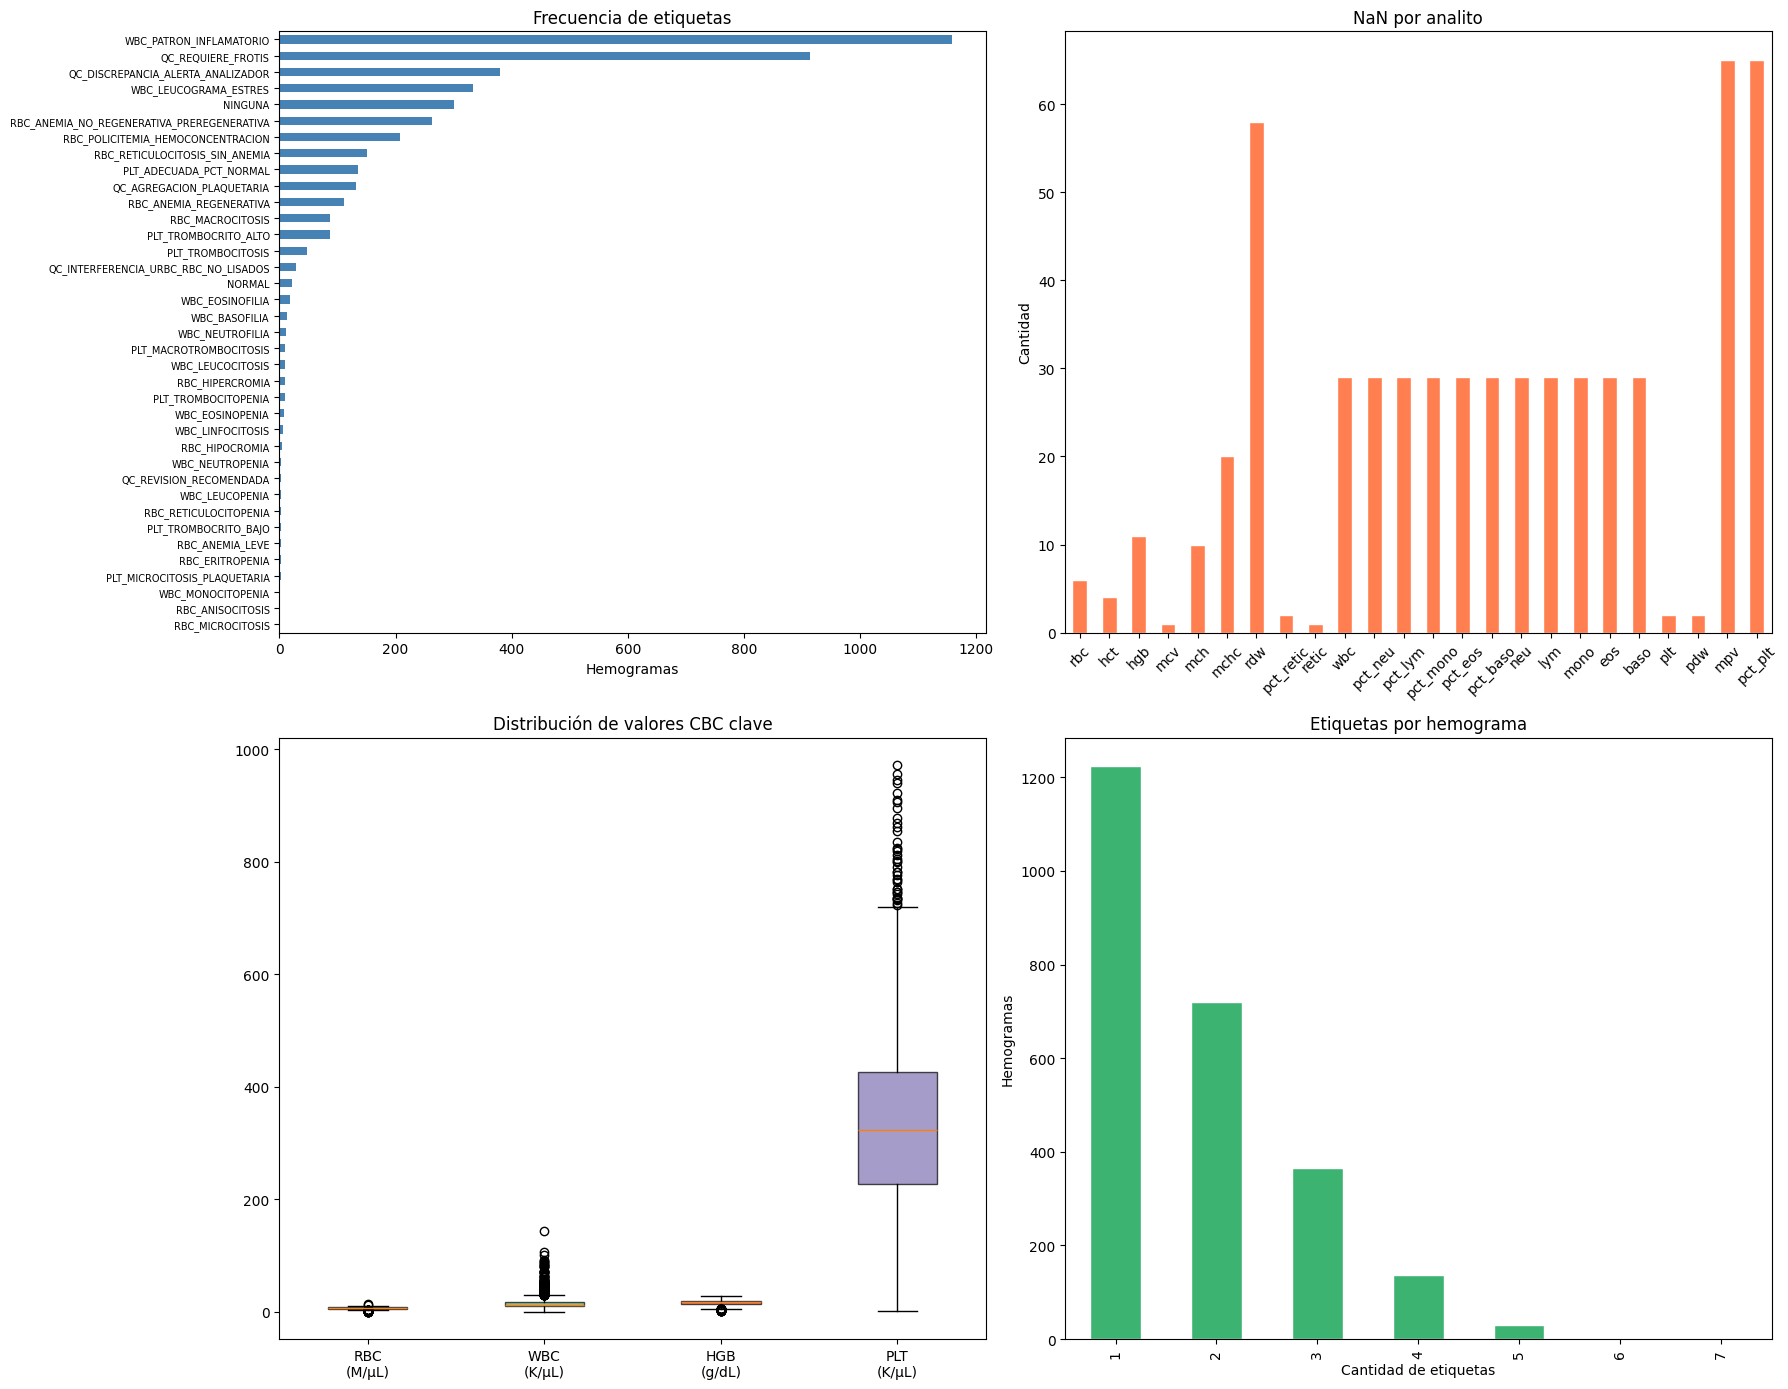

In [12]:
# 5e. Visualización QA
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Frecuencia de etiquetas
label_cols = [f"label_{l}" for l in LABELS]
label_sums = df[label_cols].sum().sort_values(ascending=True)
label_sums.index = [c.replace("label_", "") for c in label_sums.index]
label_sums.plot.barh(ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Frecuencia de etiquetas")
axes[0, 0].set_xlabel("Hemogramas")
axes[0, 0].tick_params(axis="y", labelsize=7)

# 2. NaN por analito
value_cols = [f"{col}_value" for col in COL_NAMES]
nan_per_analyte = df[value_cols].isna().sum()
nan_per_analyte.index = [c.replace("_value", "") for c in nan_per_analyte.index]
nan_per_analyte.plot.bar(ax=axes[0, 1], color="coral", edgecolor="white")
axes[0, 1].set_title("NaN por analito")
axes[0, 1].set_ylabel("Cantidad")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Box plots de valores CBC clave
key = {"rbc": "RBC\n(M/µL)", "wbc": "WBC\n(K/µL)", "hgb": "HGB\n(g/dL)", "plt": "PLT\n(K/µL)"}
data_bp = [df[f"{k}_value"].dropna().values for k in key]
bp = axes[1, 0].boxplot(data_bp, tick_labels=list(key.values()), patch_artist=True)
colors_bp = ["#4c72b0", "#55a868", "#c44e52", "#8172b2"]
for patch, c in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1, 0].set_title("Distribución de valores CBC clave")

# 4. Etiquetas por hemograma
n_lbl = df[label_cols].sum(axis=1)
n_lbl.value_counts().sort_index().plot.bar(ax=axes[1, 1], color="mediumseagreen", edgecolor="white")
axes[1, 1].set_title("Etiquetas por hemograma")
axes[1, 1].set_xlabel("Cantidad de etiquetas")
axes[1, 1].set_ylabel("Hemogramas")

plt.tight_layout()
plt.show()

---
## 6. Armonizacion del Dataset DAP (Dog Aging Project)

El [Dog Aging Project (DAP)](https://dogagingproject.org/) proporciona datos CBC de una cohorte de perros en EE.UU.
Este dataset se integra con los datos locales para aumentar el volumen de entrenamiento.

**Pasos:**
1. Cargar el DAP desde CSV
2. Mapear columnas al esquema local de 24 analitos
3. Recrear flags H/L usando rangos de referencia caninos IDEXX
4. Aplicar etiquetado determinista (Capa A)
5. Marcar `source = 'DAP'` y unificar con datos locales

> **Nota:** El DAP **no tiene PDW** (Platelet Distribution Width), se excluye de los analitos DAP.

In [13]:
# -- 6a. Cargar dataset DAP ----------------------------------------
DAP_CSV = Path("DAP_2023_SamplesResults_CBC_v1.0.csv")

df_dap_raw = pd.read_csv(DAP_CSV)
print(f"DAP raw: {df_dap_raw.shape[0]} filas x {df_dap_raw.shape[1]} columnas")
print(f"Columnas numericas DAP:")
for c in df_dap_raw.select_dtypes(include='number').columns:
    print(f"  {c}")

DAP raw: 1681 filas x 50 columnas
Columnas numericas DAP:
  dog_id
  krt_cbc_total_wbcs
  krt_cbc_abs_metamyelocytes
  krt_cbc_abs_bands
  krt_cbc_abs_neutrophils
  krt_cbc_abs_lymphocytes
  krt_cbc_abs_monocytes
  krt_cbc_abs_eosinophils
  krt_cbc_abs_basophils
  krt_cbc_abs_other_cells
  krt_cbc_rel_metamyelocytes
  krt_cbc_rel_bands
  krt_cbc_rel_neutrophils
  krt_cbc_rel_lymphocytes
  krt_cbc_rel_monocytes
  krt_cbc_rel_eosinophils
  krt_cbc_rel_basophils
  krt_cbc_rel_other_cells
  krt_cbc_rbc
  krt_cbc_hgb
  krt_cbc_hct
  krt_cbc_pcv
  krt_cbc_mcv
  krt_cbc_mch
  krt_cbc_mchc
  krt_cbc_rdw
  krt_cbc_plt
  krt_cbc_mpv
  krt_cbc_pct
  krt_cbc_nucleated_rbcs
  krt_cbc_retic_per
  krt_cbc_retic_abs


In [14]:
# -- 6b. Mapeo de columnas DAP -> esquema local ----------------
#
# DAP usa prefijo krt_cbc_. Mapeamos a nuestro esquema de 24 analitos.
# PDW no esta disponible en DAP.

DAP_COLUMN_MAP = {
    "krt_cbc_rbc":              "rbc",
    "krt_cbc_hct":              "hct",
    "krt_cbc_hgb":              "hgb",
    "krt_cbc_mcv":              "mcv",
    "krt_cbc_mch":              "mch",
    "krt_cbc_mchc":             "mchc",
    "krt_cbc_rdw":              "rdw",
    "krt_cbc_retic_per":        "pct_retic",
    "krt_cbc_retic_abs":        "retic",
    "krt_cbc_total_wbcs":       "wbc",
    "krt_cbc_rel_neutrophils":  "pct_neu",
    "krt_cbc_rel_lymphocytes":  "pct_lym",
    "krt_cbc_rel_monocytes":    "pct_mono",
    "krt_cbc_rel_eosinophils":  "pct_eos",
    "krt_cbc_rel_basophils":    "pct_baso",
    "krt_cbc_abs_neutrophils":  "neu",
    "krt_cbc_abs_lymphocytes":  "lym",
    "krt_cbc_abs_monocytes":    "mono",
    "krt_cbc_abs_eosinophils":  "eos",
    "krt_cbc_abs_basophils":    "baso",
    "krt_cbc_plt":              "plt",
    "krt_cbc_mpv":              "mpv",
    "krt_cbc_pct":              "pct_plt",
}

# Rangos de referencia caninos IDEXX (mismos del analizador local)
IDEXX_RANGES = {
    "rbc":      (5.65,  8.87,  "M/uL"),
    "hct":      (37.3,  61.7,  "%"),
    "hgb":      (13.1,  20.5,  "g/dL"),
    "mcv":      (61.6,  73.5,  "fL"),
    "mch":      (21.2,  25.9,  "pg"),
    "mchc":     (32.0,  37.9,  "g/dL"),
    "rdw":      (13.6,  21.7,  "%"),
    "pct_retic":(None,  None,  "%"),
    "retic":    (10.0,  110.0, "K/uL"),
    "wbc":      (5.05,  16.76, "K/uL"),
    "pct_neu":  (None,  None,  "%"),
    "pct_lym":  (None,  None,  "%"),
    "pct_mono": (None,  None,  "%"),
    "pct_eos":  (None,  None,  "%"),
    "pct_baso": (None,  None,  "%"),
    "neu":      (2.95,  11.64, "K/uL"),
    "lym":      (1.05,  5.10,  "K/uL"),
    "mono":     (0.16,  1.12,  "K/uL"),
    "eos":      (0.06,  1.23,  "K/uL"),
    "baso":     (0.0,   0.10,  "K/uL"),
    "plt":      (148.0, 484.0, "K/uL"),
    "mpv":      (8.7,   13.2,  "fL"),
    "pct_plt":  (0.14,  0.46,  "%"),
}

print(f"Analitos mapeados: {len(DAP_COLUMN_MAP)} (PDW excluido)")
print(f"Rangos IDEXX definidos: {len(IDEXX_RANGES)}")

Analitos mapeados: 23 (PDW excluido)
Rangos IDEXX definidos: 23


In [15]:
# -- 6c. Transformar DAP al esquema local ----------------------

def transform_dap_to_local(df_raw, col_map, ranges):
    """
    Transforma DataFrame DAP al esquema local.
    Crea: {col}_value, _unit, _ref_low, _ref_high, _flag para cada analito.
    """
    records = []
    for idx, row in tqdm(df_raw.iterrows(), total=len(df_raw), desc="Transformando DAP"):
        rec = {
            "file_name": f"DAP_{row.get('dog_id', 'unk')}_{row.get('DAP_Sample_ID', idx)}",
            "file_path": "DAP",
            "batch": "DAP",
            "tipo": "DAP",
            "report_date": str(row.get("Sample_Year", "")),
            "report_time": None,
            "is_multicolumn": False,
        }
        
        for dap_col, local_col in col_map.items():
            val = row.get(dap_col, float("nan"))
            try:
                val = float(val)
            except (ValueError, TypeError):
                val = float("nan")
            rec[f"{local_col}_value"] = val
            
            ref_low, ref_high, unit = ranges.get(local_col, (None, None, ""))
            rec[f"{local_col}_ref_low"]  = ref_low if ref_low is not None else float("nan")
            rec[f"{local_col}_ref_high"] = ref_high if ref_high is not None else float("nan")
            rec[f"{local_col}_unit"] = unit
            
            flag = ""
            if not pd.isna(val) and ref_low is not None and ref_high is not None:
                if val > ref_high: flag = "H"
                elif val < ref_low: flag = "L"
            rec[f"{local_col}_flag"] = flag
        
        for sfx in ("_value","_ref_low","_ref_high"):
            rec[f"pdw{sfx}"] = float("nan")
        rec["pdw_unit"] = ""
        rec["pdw_flag"] = ""
        
        cmt = row.get("krt_cbc_test_comments", "")
        rec["page2_comments"] = str(cmt) if pd.notna(cmt) else ""
        rec["parse_issues"] = ""
        records.append(rec)
    
    return pd.DataFrame(records)


df_dap = transform_dap_to_local(df_dap_raw, DAP_COLUMN_MAP, IDEXX_RANGES)
print(f"\nDAP transformado: {df_dap.shape}")

flag_cols_dap = [c for c in df_dap.columns if c.endswith('_flag')]
print(f"\nFlags recreados (registros con al menos 1 flag):")
for fc in flag_cols_dap:
    n_h = (df_dap[fc] == 'H').sum()
    n_l = (df_dap[fc] == 'L').sum()
    if n_h + n_l > 0:
        print(f"  {fc:20s}  H={n_h:4d}  L={n_l:4d}")

Transformando DAP:   0%|          | 0/1681 [00:00<?, ?it/s]


DAP transformado: (1681, 129)

Flags recreados (registros con al menos 1 flag):
  rbc_flag              H=  19  L=  55
  hct_flag              H=  78  L=  13
  hgb_flag              H=  91  L=  31
  mcv_flag              H= 893  L=   5
  mch_flag              H= 198  L=   9
  mchc_flag             H=   5  L= 114
  rdw_flag              H=   0  L=1615
  retic_flag            H= 156  L=   4
  wbc_flag              H=  11  L= 154
  neu_flag              H=  15  L= 116
  lym_flag              H=   4  L= 336
  mono_flag             H=  25  L= 272
  eos_flag              H=  73  L=  80
  baso_flag             H=  11  L=   0
  plt_flag              H=  60  L=  29
  mpv_flag              H= 656  L= 154
  pct_plt_flag          H= 234  L=  15


### 6c-bis. Verificación de Unidades DAP -> Local

Se verifica que las unidades asignadas a cada analito del DAP son
compatibles con las del dataset local. Esto es obligatorio para
reproducibilidad (TRIPOD+AI).

In [16]:
# -- 6c-bis. Verificación de unidades DAP vs LOCAL ---------------

print("=== Verificación de unidades DAP → LOCAL ===\n")

unit_issues = []
for col in COL_NAMES:
    ucol = f"{col}_unit"
    if ucol not in df.columns or ucol not in df_dap.columns:
        continue
    local_units = df[ucol].dropna().unique()
    dap_units = df_dap[ucol].dropna().unique()
    local_set = set(str(u).strip() for u in local_units if str(u).strip())
    dap_set = set(str(u).strip() for u in dap_units if str(u).strip())
    match = "✓" if local_set == dap_set else "✗"
    if local_set != dap_set:
        unit_issues.append(col)
    print(f"  {col:15s}  LOCAL={local_set}  DAP={dap_set}  {match}")

if unit_issues:
    print(f"\n[WARN] Discrepancias en: {unit_issues}")
else:
    print("\n[OK] Todas las unidades son compatibles.")

# Versionar el mapeo
print(f"\nVersión del mapeo DAP→LOCAL: v1.0 ({len(DAP_COLUMN_MAP)} analitos)")
print(f"Rangos IDEXX definidos: {len(IDEXX_RANGES)}")

=== Verificación de unidades DAP → LOCAL ===

  rbc              LOCAL={'M/µL'}  DAP={'M/uL'}  ✗
  hct              LOCAL={'%'}  DAP={'%'}  ✓
  hgb              LOCAL={'g/dL'}  DAP={'g/dL'}  ✓
  mcv              LOCAL={'fL'}  DAP={'fL'}  ✓
  mch              LOCAL={'pg'}  DAP={'pg'}  ✓
  mchc             LOCAL={'g/dL'}  DAP={'g/dL'}  ✓
  rdw              LOCAL={'%'}  DAP={'%'}  ✓
  pct_retic        LOCAL={'%'}  DAP={'%'}  ✓
  retic            LOCAL={'K/µL'}  DAP={'K/uL'}  ✗
  wbc              LOCAL={'K/µL'}  DAP={'K/uL'}  ✗
  pct_neu          LOCAL={'%'}  DAP={'%'}  ✓
  pct_lym          LOCAL={'%'}  DAP={'%'}  ✓
  pct_mono         LOCAL={'%'}  DAP={'%'}  ✓
  pct_eos          LOCAL={'%'}  DAP={'%'}  ✓
  pct_baso         LOCAL={'%'}  DAP={'%'}  ✓
  neu              LOCAL={'K/µL'}  DAP={'K/uL'}  ✗
  lym              LOCAL={'K/µL'}  DAP={'K/uL'}  ✗
  mono             LOCAL={'K/µL'}  DAP={'K/uL'}  ✗
  eos              LOCAL={'K/µL'}  DAP={'K/uL'}  ✗
  baso             LOCAL={'K/µL'}  DAP={'

### 6d. Etiquetado Determinista (Capa A) para DAP

Reglas basadas en flags H/L para asignar las 37 etiquetas del proyecto.
Este etiquetado es **independiente del experto** - se deriva directamente de los rangos de referencia.

| Grupo | Regla ejemplo |
|---|---|
| PLT | `plt_flag == 'L'` -> PLT_TROMBOCITOPENIA |
| RBC | `hct_flag == 'L'` + `retic_flag == 'H'` -> RBC_ANEMIA_REGENERATIVA |
| WBC | `neu_flag == 'H'` + `lym_flag == 'L'` -> WBC_LEUCOGRAMA_ESTRES |

In [17]:
# -- 6d. Etiquetado determinista (Capa A) ----------------------

def apply_deterministic_labels(df_data, labels_list):
    """
    Aplica etiquetado determinista basado en flags H/L.
    Crea columnas booleanas label_{ETIQUETA} para cada etiqueta.
    """
    for lbl in labels_list:
        df_data[f"label_{lbl}"] = False
    
    for idx in tqdm(range(len(df_data)), desc="Etiquetando DAP"):
        row = df_data.iloc[idx]
        active = []
        
        # -- PLT --
        plt_f    = row.get("plt_flag", "")
        pctplt_f = row.get("pct_plt_flag", "")
        mpv_f    = row.get("mpv_flag", "")
        plt_v    = row.get("plt_value", float("nan"))
        pctplt_v = row.get("pct_plt_value", float("nan"))
        
        if plt_f == "L":  active.append("PLT_TROMBOCITOPENIA")
        elif plt_f == "H": active.append("PLT_TROMBOCITOSIS")
        if pctplt_f == "H": active.append("PLT_TROMBOCRITO_ALTO")
        elif pctplt_f == "L": active.append("PLT_TROMBOCRITO_BAJO")
        if mpv_f == "H": active.append("PLT_MACROTROMBOCITOSIS")
        elif mpv_f == "L": active.append("PLT_MICROCITOSIS_PLAQUETARIA")
        if plt_f == "" and pctplt_f == "" and not pd.isna(plt_v) and not pd.isna(pctplt_v):
            active.append("PLT_ADECUADA_PCT_NORMAL")
        
        # -- RBC --
        rbc_f   = row.get("rbc_flag", "")
        hct_f   = row.get("hct_flag", "")
        hgb_f   = row.get("hgb_flag", "")
        mcv_f   = row.get("mcv_flag", "")
        mch_f   = row.get("mch_flag", "")
        mchc_f  = row.get("mchc_flag", "")
        rdw_f   = row.get("rdw_flag", "")
        retic_f = row.get("retic_flag", "")
        
        if rbc_f == "L": active.append("RBC_ERITROPENIA")
        
        is_anemia = (hct_f == "L" or hgb_f == "L")
        if is_anemia:
            active.append("RBC_ANEMIA_LEVE")
            if retic_f == "H": active.append("RBC_ANEMIA_REGENERATIVA")
            else: active.append("RBC_ANEMIA_NO_REGENERATIVA_PREREGENERATIVA")
        
        if hct_f == "H": active.append("RBC_POLICITEMIA_HEMOCONCENTRACION")
        if mcv_f == "H": active.append("RBC_MACROCITOSIS")
        elif mcv_f == "L": active.append("RBC_MICROCITOSIS")
        if mchc_f == "H" or mch_f == "H": active.append("RBC_HIPERCROMIA")
        elif mchc_f == "L" or mch_f == "L": active.append("RBC_HIPOCROMIA")
        if rdw_f == "H": active.append("RBC_ANISOCITOSIS")
        if retic_f == "L": active.append("RBC_RETICULOCITOPENIA")
        elif retic_f == "H" and not is_anemia: active.append("RBC_RETICULOCITOSIS_SIN_ANEMIA")
        
        # -- WBC --
        wbc_f  = row.get("wbc_flag", "")
        neu_f  = row.get("neu_flag", "")
        lym_f  = row.get("lym_flag", "")
        mono_f = row.get("mono_flag", "")
        eos_f  = row.get("eos_flag", "")
        baso_f = row.get("baso_flag", "")
        
        if wbc_f == "H": active.append("WBC_LEUCOCITOSIS")
        elif wbc_f == "L": active.append("WBC_LEUCOPENIA")
        if neu_f == "H": active.append("WBC_NEUTROFILIA")
        elif neu_f == "L": active.append("WBC_NEUTROPENIA")
        if lym_f == "H": active.append("WBC_LINFOCITOSIS")
        if mono_f == "H": active.append("WBC_PATRON_INFLAMATORIO")
        if mono_f == "L": active.append("WBC_MONOCITOPENIA")
        if eos_f == "H": active.append("WBC_EOSINOFILIA")
        elif eos_f == "L": active.append("WBC_EOSINOPENIA")
        if baso_f == "H": active.append("WBC_BASOFILIA")
        if neu_f == "H" and lym_f == "L": active.append("WBC_LEUCOGRAMA_ESTRES")
        
        # -- Asignar --
        if not active:
            df_data.at[df_data.index[idx], "label_NORMAL"] = True
        else:
            for lbl in active:
                c = f"label_{lbl}"
                if c in df_data.columns:
                    df_data.at[df_data.index[idx], c] = True
    return df_data


df_dap = apply_deterministic_labels(df_dap, LABELS)

# Resumen
label_cols = [f"label_{l}" for l in LABELS]
print("\n=== Distribucion de etiquetas DAP (Capa A) ===")
lbl_sums = df_dap[label_cols].sum().sort_values(ascending=False)
for c, n in lbl_sums.items():
    if n > 0:
        print(f"  {c.replace('label_',''):45s}: {int(n):5d}  ({n/len(df_dap)*100:.1f}%)")
print(f"\nTotal DAP: {len(df_dap)} | NORMAL: {int(df_dap['label_NORMAL'].sum())}")

Etiquetando DAP:   0%|          | 0/1681 [00:00<?, ?it/s]


=== Distribucion de etiquetas DAP (Capa A) ===
  PLT_ADECUADA_PCT_NORMAL                      :  1102  (65.6%)
  RBC_MACROCITOSIS                             :   893  (53.1%)
  PLT_MACROTROMBOCITOSIS                       :   656  (39.0%)
  WBC_MONOCITOPENIA                            :   272  (16.2%)
  PLT_TROMBOCRITO_ALTO                         :   234  (13.9%)
  RBC_HIPERCROMIA                              :   198  (11.8%)
  WBC_LEUCOPENIA                               :   154  (9.2%)
  PLT_MICROCITOSIS_PLAQUETARIA                 :   154  (9.2%)
  RBC_RETICULOCITOSIS_SIN_ANEMIA               :   151  (9.0%)
  WBC_NEUTROPENIA                              :   116  (6.9%)
  RBC_HIPOCROMIA                               :   115  (6.8%)
  WBC_EOSINOPENIA                              :    80  (4.8%)
  RBC_POLICITEMIA_HEMOCONCENTRACION            :    78  (4.6%)
  WBC_EOSINOFILIA                              :    73  (4.3%)
  PLT_TROMBOCITOSIS                            :    60  (3.6%)
 

---
## 7. Unificacion de Datasets y Deduplicacion

Se combinan los datos locales (IDEXX, Santiago de los Caballeros) con los del DAP.
La columna source permite filtrar por origen para analisis de domain shift.

In [18]:
# -- 7a. Agregar columna source y combinar --------------------

# Marcar origen
df["source"] = "LOCAL"
df_dap["source"] = "DAP"

# Combinar
df_combined = pd.concat([df, df_dap], ignore_index=True)

# Asegurar tipos booleanos
for c in label_cols:
    df_combined[c] = df_combined[c].fillna(False).astype(bool)

print(f"LOCAL:     {(df_combined['source']=='LOCAL').sum():5d} registros")
print(f"DAP:       {(df_combined['source']=='DAP').sum():5d} registros")
print(f"COMBINADO: {len(df_combined):5d} registros")

LOCAL:      2479 registros
DAP:        1681 registros
COMBINADO:  4160 registros


/tmp/ipykernel_21428/2772522477.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["source"] = "LOCAL"


In [19]:
# -- 7b. Deduplicacion por fingerprint ------------------------
import hashlib

def compute_fingerprint(row, value_cols):
    """Hash MD5 de valores numericos para detectar duplicados."""
    vals = [str(round(float(row[c]), 4)) if pd.notna(row[c]) else 'NA'
            for c in value_cols]
    return hashlib.md5('|'.join(vals).encode()).hexdigest()

# Columnas de valores (sin PDW para compatibilidad DAP)
fp_cols = [f"{col}_value" for col in COL_NAMES if col != "pdw"]

df_combined["fingerprint"] = df_combined.apply(
    lambda row: compute_fingerprint(row, fp_cols), axis=1
)

# Marcar duplicados (no eliminar - se decide en Notebook 2)
df_combined["is_duplicate"] = df_combined["fingerprint"].duplicated(keep="first")

n_dupes = df_combined["is_duplicate"].sum()
print(f"Registros totales:   {len(df_combined)}")
print(f"Duplicados marcados: {n_dupes}")
if n_dupes > 0:
    print(f"\nDuplicados por source:")
    print(df_combined[df_combined["is_duplicate"]]["source"].value_counts())

Registros totales:   4160
Duplicados marcados: 10

Duplicados por source:
source
LOCAL    10
Name: count, dtype: int64


/tmp/ipykernel_21428/612444828.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_combined["fingerprint"] = df_combined.apply(
/tmp/ipykernel_21428/612444828.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_combined["is_duplicate"] = df_combined["fingerprint"].duplicated(keep="first")


### 7b-bis. Deduplicación Ampliada: Near-Duplicates

Además de duplicados exactos (fingerprint), se detectan **near-duplicates**:
registros cuyo vector de analitos difiere por una distancia mínima.

Esto es necesario para transparencia (TRIPOD+AI [1]).

| Parámetro | Valor |
|---|---|
| Distancia | Euclidiana normalizada |
| Umbral | 0.01 |

In [20]:
# -- 7b-bis. Near-duplicate detection ----------------------------
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

NEAR_DUP_THRESHOLD = 0.01

# Usar columnas de valor (sin PDW para compat DAP)
nd_cols = [f"{col}_value" for col in COL_NAMES if col != "pdw"]
nd_matrix = df_combined[nd_cols].copy()

# Imputar NaN con mediana para cálculo de distancia
for c in nd_cols:
    nd_matrix[c] = nd_matrix[c].fillna(nd_matrix[c].median())

# Normalizar
scaler = StandardScaler()
nd_scaled = scaler.fit_transform(nd_matrix)

# Calcular distancias (esto puede ser lento con datasets grandes)
print("Calculando distancias entre registros...")
n = len(nd_scaled)

# Para eficiencia, procesamos por bloques
is_near_dup = [False] * n
near_dup_count = 0

# Usar un approach eficiente: comparar cada par solo una vez
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=2, metric='euclidean')
nn.fit(nd_scaled)
distances, indices = nn.kneighbors(nd_scaled)

# El vecino más cercano (excl. el propio punto) es distances[:, 1]
for i in range(n):
    # Si la distancia al vecino más cercano es < umbral Y no es un dup exacto
    if distances[i, 1] < NEAR_DUP_THRESHOLD and not df_combined.iloc[i].get("is_duplicate", False):
        j = indices[i, 1]
        # Marcar el segundo como near-duplicate (mantener el primero)
        if i < j:
            is_near_dup[j] = True
            near_dup_count += 1

df_combined["is_near_duplicate"] = is_near_dup

# Reporte
n_exact = df_combined["is_duplicate"].sum()
n_near = df_combined["is_near_duplicate"].sum()
print(f"\n=== Deduplicación ampliada ===")
print(f"  Duplicados exactos:        {n_exact}")
print(f"  Near-duplicates (d<{NEAR_DUP_THRESHOLD}): {n_near}")
print(f"  Total marcados:            {n_exact + n_near}")

# Por source
for src in ["LOCAL", "DAP"]:
    sub = df_combined[df_combined["source"] == src]
    print(f"  {src}: exact={sub['is_duplicate'].sum()}, near={sub['is_near_duplicate'].sum()}")

Calculando distancias entre registros...

=== Deduplicación ampliada ===
  Duplicados exactos:        10
  Near-duplicates (d<0.01): 0
  Total marcados:            10
  LOCAL: exact=10, near=0
  DAP: exact=0, near=0


/tmp/ipykernel_21428/153979649.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_combined["is_near_duplicate"] = is_near_dup


In [21]:
# -- 7c. Exportar dataset combinado ---------------------------

# Ordenar columnas
meta_cols = ["file_name", "file_path", "batch", "tipo", "report_date",
             "report_time", "is_multicolumn", "source"]

analyte_cols = []
for col in COL_NAMES:
    analyte_cols += [f"{col}{s}" for s in ("_value","_unit","_ref_low","_ref_high","_flag")]

extra_cols = ["page2_comments", "parse_issues", "fingerprint", "is_duplicate"]
ordered = meta_cols + analyte_cols + label_cols + extra_cols
df_combined = df_combined[[c for c in ordered if c in df_combined.columns]]

# Guardar combinado
csv_combined = DATA_DIR / "hemogramas_combinado.csv"
df_combined.to_csv(csv_combined, index=False)
print(f"CSV combinado: {csv_combined}")
print(f"  Shape: {df_combined.shape}")
print(f"  LOCAL: {(df_combined['source']=='LOCAL').sum()} | DAP: {(df_combined['source']=='DAP').sum()}")
print(f"  Duplicados: {df_combined['is_duplicate'].sum()} (marcados, no eliminados)")

# Re-exportar solo local (compatibilidad con Notebook 2 original)
df_local = df_combined[df_combined["source"] == "LOCAL"].drop(
    columns=["source", "fingerprint", "is_duplicate"], errors="ignore"
)
csv_local = DATA_DIR / "hemogramas_extraidos.csv"
df_local.to_csv(csv_local, index=False)
print(f"\nCSV local (compatibilidad): {csv_local}")

CSV combinado: ../data2/hemogramas_combinado.csv
  Shape: (4160, 169)
  LOCAL: 2479 | DAP: 1681
  Duplicados: 10 (marcados, no eliminados)

CSV local (compatibilidad): ../data2/hemogramas_extraidos.csv


---
## 8. QA - Validacion del Dataset Combinado

In [22]:
# -- 8. Validacion del dataset combinado ----------------------
print("=== QA: Dataset Combinado ===\n")

# 8a. NaN en columnas core
for src in ["LOCAL", "DAP"]:
    sub = df_combined[df_combined["source"] == src]
    print(f"--- {src} ({len(sub)} registros) ---")
    for a in ["rbc", "wbc", "plt", "hct", "hgb"]:
        n_na = sub[f"{a}_value"].isna().sum()
        s = "OK" if n_na == 0 else "WARN"
        print(f"  [{s}] {a}_value: {n_na} NaN ({n_na/len(sub)*100:.1f}%)")
    print()

# 8b. Comparacion medianas
print("=== Comparacion de medianas LOCAL vs DAP ===\n")
print(f"{'Analito':<15} {'LOCAL':>10} {'DAP':>10} {'Diff%':>8}")
print("-" * 45)
for col in COL_NAMES:
    vc = f"{col}_value"
    if vc not in df_combined.columns: continue
    ml = df_combined.loc[df_combined["source"]=="LOCAL", vc].median()
    md_val = df_combined.loc[df_combined["source"]=="DAP", vc].median()
    if pd.notna(ml) and pd.notna(md_val) and ml != 0:
        d = abs(md_val - ml) / abs(ml) * 100
        w = " !!" if d > 30 else ""
        print(f"  {col:<13} {ml:>10.2f} {md_val:>10.2f} {d:>7.1f}%{w}")

# 8c. Etiquetas por source
print("\n=== Etiquetas por source (top 10) ===\n")
for src in ["LOCAL", "DAP"]:
    sub = df_combined[df_combined["source"] == src]
    sums = sub[label_cols].sum().sort_values(ascending=False)
    act = sums[sums > 0]
    print(f"--- {src} ({len(sub)} reg, {len(act)} etiquetas activas) ---")
    for c, n in act.head(10).items():
        print(f"  {c.replace('label_',''):40s}: {int(n):5d} ({n/len(sub)*100:.1f}%)")
    print()

=== QA: Dataset Combinado ===

--- LOCAL (2479 registros) ---
  [WARN] rbc_value: 6 NaN (0.2%)
  [WARN] wbc_value: 29 NaN (1.2%)
  [WARN] plt_value: 2 NaN (0.1%)
  [WARN] hct_value: 4 NaN (0.2%)
  [WARN] hgb_value: 11 NaN (0.4%)

--- DAP (1681 registros) ---
  [OK] rbc_value: 0 NaN (0.0%)
  [OK] wbc_value: 0 NaN (0.0%)
  [WARN] plt_value: 380 NaN (22.6%)
  [OK] hct_value: 0 NaN (0.0%)
  [OK] hgb_value: 0 NaN (0.0%)

=== Comparacion de medianas LOCAL vs DAP ===

Analito              LOCAL        DAP    Diff%
---------------------------------------------
  rbc                 6.86       7.17     4.5%
  hct                49.20      53.00     7.7%
  hgb                17.20      17.70     2.9%
  mcv                72.10      73.80     2.4%
  mch                25.20      24.70     2.0%
  mchc               35.00      33.50     4.3%
  rdw                17.50      12.10    30.9% !!
  pct_retic           0.80       0.80     0.0%
  retic              54.90      57.80     5.3%
  wbc          

---
## 9. Data Schema y Validación de Tipos

Se define un **diccionario de datos formal** (DATA_SCHEMA) con el tipo esperado, rango fisiológico
mínimo/máximo y unidad para cada columna numérica del hemograma.

Esto permite:
- Detectar columnas con tipos mixtos (DtypeWarning)
- Señalizar valores fuera de rango físico (e.g. PLT < 0)
- Crear una columna schema_violations por registro para trazabilidad

> **Referencia:** TRIPOD+AI [10] recomienda declarar el esquema de datos y su validación.

In [23]:
# -- 9a. Definición de Data Schema y validación ----------------

# Rangos fisiológicos máximos (valores extremos pero biológicamente posibles)
DATA_SCHEMA = {
    # col_prefix:  (tipo, min_fisiol, max_fisiol, unidad)
    "rbc":       ("float", 0.0,  20.0,   "M/µL"),
    "hct":       ("float", 0.0,  100.0,  "%"),
    "hgb":       ("float", 0.0,  30.0,   "g/dL"),
    "mcv":       ("float", 20.0, 150.0,  "fL"),
    "mch":       ("float", 5.0,  50.0,   "pg"),
    "mchc":      ("float", 15.0, 50.0,   "g/dL"),
    "rdw":       ("float", 5.0,  40.0,   "%"),
    "pct_retic": ("float", 0.0,  50.0,   "%"),
    "retic":     ("float", 0.0,  500.0,  "K/µL"),
    "wbc":       ("float", 0.0,  200.0,  "K/µL"),
    "pct_neu":   ("float", 0.0,  100.0,  "%"),
    "pct_lym":   ("float", 0.0,  100.0,  "%"),
    "pct_mono":  ("float", 0.0,  100.0,  "%"),
    "pct_eos":   ("float", 0.0,  100.0,  "%"),
    "pct_baso":  ("float", 0.0,  100.0,  "%"),
    "neu":       ("float", 0.0,  100.0,  "K/µL"),
    "lym":       ("float", 0.0,  50.0,   "K/µL"),
    "mono":      ("float", 0.0,  30.0,   "K/µL"),
    "eos":       ("float", 0.0,  30.0,   "K/µL"),
    "baso":      ("float", 0.0,  10.0,   "K/µL"),
    "plt":       ("float", 0.0,  2000.0, "K/µL"),
    "mpv":       ("float", 2.0,  30.0,   "fL"),
    "pct_plt":   ("float", 0.0,  5.0,    "%"),
    "pdw":       ("float", 0.0,  40.0,   "fL"),
}

VALID_FLAGS = {"", "H", "L"}

print("=== 9. Validación de Data Schema ===\n")

violations_list = []  # una lista por registro
for i in range(len(df_combined)):
    violations_list.append([])

# 9a-1. Validar tipos y rangos para cada analito
for col_prefix, (dtype, lo, hi, unit) in DATA_SCHEMA.items():
    vcol = f"{col_prefix}_value"
    fcol = f"{col_prefix}_flag"
    if vcol not in df_combined.columns:
        continue

    # Forzar tipo numérico
    df_combined[vcol] = pd.to_numeric(df_combined[vcol], errors="coerce")

    # Valores fuera de rango
    vals = df_combined[vcol]
    below = vals < lo
    above = vals > hi
    n_below = below.sum()
    n_above = above.sum()
    if n_below > 0 or n_above > 0:
        print(f"  {vcol:20s}: {n_below} bajo mín ({lo}), {n_above} sobre máx ({hi})")
        for idx in df_combined.index[below]:
            pos = df_combined.index.get_loc(idx)
            violations_list[pos].append(f"{vcol}<{lo}")
        for idx in df_combined.index[above]:
            pos = df_combined.index.get_loc(idx)
            violations_list[pos].append(f"{vcol}>{hi}")

    # Validar flags
    if fcol in df_combined.columns:
        bad_flags = ~df_combined[fcol].fillna("").isin(VALID_FLAGS)
        n_bad = bad_flags.sum()
        if n_bad > 0:
            print(f"  {fcol:20s}: {n_bad} flags inválidos")
            for idx in df_combined.index[bad_flags]:
                pos = df_combined.index.get_loc(idx)
                violations_list[pos].append(f"{fcol}_invalid")

df_combined["schema_violations"] = [
    "|".join(v) if v else "" for v in violations_list
]

n_with_violations = (df_combined["schema_violations"] != "").sum()
print(f"\nRegistros con violaciones de schema: {n_with_violations} / {len(df_combined)}")
print(f"Registros limpios: {len(df_combined) - n_with_violations}")

=== 9. Validación de Data Schema ===

  mcv_value           : 2 bajo mín (20.0), 0 sobre máx (150.0)
  mch_value           : 0 bajo mín (5.0), 5 sobre máx (50.0)
  mchc_value          : 0 bajo mín (15.0), 10 sobre máx (50.0)
  rdw_value           : 3 bajo mín (5.0), 3 sobre máx (40.0)
  pct_retic_value     : 0 bajo mín (0.0), 1 sobre máx (50.0)
  retic_value         : 0 bajo mín (0.0), 4 sobre máx (500.0)
  neu_value           : 0 bajo mín (0.0), 1 sobre máx (100.0)
  lym_value           : 0 bajo mín (0.0), 3 sobre máx (50.0)
  mpv_value           : 0 bajo mín (2.0), 12 sobre máx (30.0)

Registros con violaciones de schema: 37 / 4160
Registros limpios: 4123


/tmp/ipykernel_21428/3993994779.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_combined["schema_violations"] = [


---
## 10. Control de Calidad: Gold / Silver / Reject

Se clasifica cada registro según su nivel de confiabilidad usando un enfoque **data-centric**:

| Tier | Criterio |
|---|---|
| **Gold** | Sin parse_issues, sin schema_violations, sin NaN en analitos core |
| **Silver** | parse_issues leves O NaN en analitos secundarios, sin violaciones graves |
| **Reject** | Violaciones de schema graves (valores fuera de rango fisiológico extremo) |

> **Impacto:** Permite reportar cómo cambia el desempeño al entrenar en Gold vs Gold+Silver.

In [24]:
# -- 10a. Clasificación por calidad Gold/Silver/Reject ---------

CORE_ANALYTES = ["rbc_value", "wbc_value", "plt_value", "hct_value", "hgb_value"]

def assign_quality_tier(row):
    """Asigna Gold / Silver / Reject basado en calidad del registro."""
    sv = str(row.get("schema_violations", ""))
    pi = str(row.get("parse_issues", ""))
    
    # Reject: violaciones de schema graves
    if sv:
        # Contar cuántas violaciones
        n_violations = len(sv.split("|"))
        if n_violations >= 3:
            return "Reject"
    
    # Verificar NaN en analitos core
    core_nan = sum(1 for c in CORE_ANALYTES if pd.isna(row.get(c)))
    
    # Gold: sin issues, sin violations, sin NaN core
    if not sv and not pi and core_nan == 0:
        return "Gold"
    
    # Silver: issues leves o NaN no-core
    return "Silver"


df_combined["quality_tier"] = df_combined.apply(assign_quality_tier, axis=1)

print("=== 10. Calidad de Registros ===\n")
print("Global:")
for tier in ["Gold", "Silver", "Reject"]:
    n = (df_combined["quality_tier"] == tier).sum()
    print(f"  {tier:8s}: {n:5d} ({n/len(df_combined)*100:.1f}%)")

print("\nPor source:")
for src in ["LOCAL", "DAP"]:
    sub = df_combined[df_combined["source"] == src]
    print(f"  --- {src} ({len(sub)} reg) ---")
    for tier in ["Gold", "Silver", "Reject"]:
        n = (sub["quality_tier"] == tier).sum()
        print(f"    {tier:8s}: {n:5d} ({n/len(sub)*100:.1f}%)")

=== 10. Calidad de Registros ===

Global:
  Gold    :  3636 (87.4%)
  Silver  :   523 (12.6%)
  Reject  :     1 (0.0%)

Por source:
  --- LOCAL (2479 reg) ---
    Gold    :  2345 (94.6%)
    Silver  :   133 (5.4%)
    Reject  :     1 (0.0%)
  --- DAP (1681 reg) ---
    Gold    :  1291 (76.8%)
    Silver  :   390 (23.2%)
    Reject  :     0 (0.0%)


/tmp/ipykernel_21428/1057060554.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_combined["quality_tier"] = df_combined.apply(assign_quality_tier, axis=1)


---
## 11. Targets Core: Trombocitopenia + Alteraciones Linfocitarias

Se crean etiquetas deterministas **directamente desde valores numéricos** (no flags),
alineadas al título de la tesis.

### Trombocitopenia (PLT < 148 K/uL)
| Severidad | Rango PLT | Relevancia clínica |
|---|---|---|
| Leve | 100-147 | Monitoreo |
| Moderada | 50-99 | Intervención posible |
| Severa | < 50 | Urgencia clínica |

### Alteraciones Linfocitarias
| Condición | Umbral (IDEXX canino) |
|---|---|
| Linfopenia | LYM < 1.05 K/uL |
| Linfocitosis | LYM > 5.10 K/uL |

In [25]:
# -- 11a. Targets core por valor numérico ----------------------

# --- Trombocitopenia por severidad ---
plt_val = df_combined["plt_value"]
df_combined["label_CORE_TROMBOCITOPENIA"] = plt_val < 148.0

def classify_severity(v):
    if pd.isna(v) or v >= 148.0:
        return "none"
    elif v >= 100.0:
        return "leve"
    elif v >= 50.0:
        return "moderada"
    else:
        return "severa"

df_combined["trombocitopenia_severity"] = plt_val.apply(classify_severity)

# --- Alteraciones Linfocitarias ---
lym_val = df_combined["lym_value"]
df_combined["label_CORE_LINFOPENIA"] = lym_val < 1.05
df_combined["label_CORE_LINFOCITOSIS"] = lym_val > 5.10

# --- Reporte ---
print("=== 11. Targets Core (por valor numérico) ===\n")

print("Trombocitopenia (PLT < 148):")
for src in ["LOCAL", "DAP", "TOTAL"]:
    sub = df_combined if src == "TOTAL" else df_combined[df_combined["source"] == src]
    n_pos = sub["label_CORE_TROMBOCITOPENIA"].sum()
    print(f"  {src:8s}: {int(n_pos):5d} / {len(sub)} ({n_pos/len(sub)*100:.1f}%)")

print("\nSeveridad de trombocitopenia:")
sev_counts = df_combined["trombocitopenia_severity"].value_counts()
for sev in ["leve", "moderada", "severa"]:
    n = sev_counts.get(sev, 0)
    print(f"  {sev:10s}: {n:5d}")

print("\nSeveridad por source:")
for src in ["LOCAL", "DAP"]:
    sub = df_combined[df_combined["source"] == src]
    sev_sub = sub["trombocitopenia_severity"].value_counts()
    print(f"  {src}: ", end="")
    for sev in ["leve", "moderada", "severa"]:
        print(f"{sev}={sev_sub.get(sev, 0)}  ", end="")
    print()

print("\nAlteraciones linfocitarias:")
for lbl in ["label_CORE_LINFOPENIA", "label_CORE_LINFOCITOSIS"]:
    n_total = int(df_combined[lbl].sum())
    n_local = int(df_combined.loc[df_combined["source"]=="LOCAL", lbl].sum())
    n_dap   = int(df_combined.loc[df_combined["source"]=="DAP", lbl].sum())
    print(f"  {lbl.replace('label_CORE_',''):15s}: LOCAL={n_local:4d}  DAP={n_dap:4d}  TOTAL={n_total:4d}")

# Comparar con etiquetas existentes
print("\n--- Comparación CORE vs etiquetas existentes ---")
if "label_PLT_TROMBOCITOPENIA" in df_combined.columns:
    both = (df_combined["label_CORE_TROMBOCITOPENIA"] & df_combined["label_PLT_TROMBOCITOPENIA"]).sum()
    core_only = (df_combined["label_CORE_TROMBOCITOPENIA"] & ~df_combined["label_PLT_TROMBOCITOPENIA"]).sum()
    old_only = (~df_combined["label_CORE_TROMBOCITOPENIA"] & df_combined["label_PLT_TROMBOCITOPENIA"]).sum()
    print(f"  Trombocitopenia: coinciden={int(both)}, solo_CORE={int(core_only)}, solo_flag={int(old_only)}")

/tmp/ipykernel_21428/2067859852.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_combined["label_CORE_TROMBOCITOPENIA"] = plt_val < 148.0
/tmp/ipykernel_21428/2067859852.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_combined["trombocitopenia_severity"] = plt_val.apply(classify_severity)
/tmp/ipykernel_21428/2067859852.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using p

=== 11. Targets Core (por valor numérico) ===

Trombocitopenia (PLT < 148):
  LOCAL   :   316 / 2479 (12.7%)
  DAP     :    29 / 1681 (1.7%)
  TOTAL   :   345 / 4160 (8.3%)

Severidad de trombocitopenia:
  leve      :   155
  moderada  :   119
  severa    :    71

Severidad por source:


  LOCAL: leve=137  moderada=112  severa=67  
  DAP: leve=18  moderada=7  severa=4  

Alteraciones linfocitarias:
  LINFOPENIA     : LOCAL= 444  DAP= 336  TOTAL= 780
  LINFOCITOSIS   : LOCAL= 140  DAP=   4  TOTAL= 144

--- Comparación CORE vs etiquetas existentes ---
  Trombocitopenia: coinciden=38, solo_CORE=307, solo_flag=0


---
## 12. Auditoría de Labels (Weak Supervision)

Las etiquetas del dataset provienen de **weak supervision** (reglas + comentarios del analizador).
Esto es metodológicamente válido si se gestiona el ruido.

Este módulo:
1. Detecta **conflictos** entre etiqueta asignada y valor numérico
2. Clasifica la **fuente** de cada etiqueta (Capa A: regla, Capa B: comentario)
3. Calcula un **score de confianza** por registro


In [26]:
# -- 12a. Auditoría de labels: conflictos y confianza ----------

# Reglas de concordancia valor↔etiqueta
AUDIT_RULES = [
    # (label_col, value_col, expected_condition_fn, description)
    ("label_PLT_TROMBOCITOPENIA", "plt_value",  lambda v: v < 148,  "PLT < 148"),
    ("label_PLT_TROMBOCITOSIS",   "plt_value",  lambda v: v > 484,  "PLT > 484"),
    ("label_WBC_LEUCOCITOSIS",    "wbc_value",  lambda v: v > 16.76, "WBC > 16.76"),
    ("label_WBC_LEUCOPENIA",      "wbc_value",  lambda v: v < 5.05,  "WBC < 5.05"),
    ("label_WBC_NEUTROFILIA",     "neu_value",  lambda v: v > 11.64, "NEU > 11.64"),
    ("label_WBC_NEUTROPENIA",     "neu_value",  lambda v: v < 2.95,  "NEU < 2.95"),
    ("label_WBC_LINFOCITOSIS",    "lym_value",  lambda v: v > 5.10,  "LYM > 5.10"),
    ("label_RBC_POLICITEMIA_HEMOCONCENTRACION", "hct_value", lambda v: v > 61.7, "HCT > 61.7"),
]

print("=== 12. Auditoría de Labels ===\n")
print(f"{'Etiqueta':45s} {'Pos':>5s} {'Concordan':>10s} {'Conflicto':>10s} {'Tasa%':>7s}")
print("-" * 80)

total_conflicts = 0
for label_col, value_col, cond_fn, desc in AUDIT_RULES:
    if label_col not in df_combined.columns:
        continue
    if value_col not in df_combined.columns:
        continue
    
    # Registros con la etiqueta positiva
    positives = df_combined[df_combined[label_col] == True]
    n_pos = len(positives)
    if n_pos == 0:
        continue
    
    # De esos, cuántos cumplen la condición numérica
    has_value = positives[value_col].notna()
    meets_cond = positives.loc[has_value, value_col].apply(cond_fn)
    n_concordant = meets_cond.sum()
    n_conflict = has_value.sum() - n_concordant
    rate = n_concordant / has_value.sum() * 100 if has_value.sum() > 0 else 0
    
    total_conflicts += n_conflict
    lbl_short = label_col.replace("label_", "")
    print(f"  {lbl_short:43s} {n_pos:5d} {int(n_concordant):10d} {int(n_conflict):10d} {rate:6.1f}%")

print(f"\nTotal conflictos detectados: {total_conflicts}")

# --- Clasificar fuente de etiqueta ---
# Capa A: etiquetas que se derivan de reglas (flags/valores numéricos)
# Capa B: etiquetas que requieren comentarios del analizador
CAPA_A_LABELS = [
    "PLT_TROMBOCITOPENIA", "PLT_TROMBOCITOSIS", "PLT_TROMBOCRITO_ALTO",
    "PLT_TROMBOCRITO_BAJO", "PLT_MACROTROMBOCITOSIS", "PLT_MICROCITOSIS_PLAQUETARIA",
    "PLT_ADECUADA_PCT_NORMAL",
    "RBC_ERITROPENIA", "RBC_ANEMIA_LEVE", "RBC_ANEMIA_REGENERATIVA",
    "RBC_ANEMIA_NO_REGENERATIVA_PREREGENERATIVA", "RBC_POLICITEMIA_HEMOCONCENTRACION",
    "RBC_MACROCITOSIS", "RBC_MICROCITOSIS", "RBC_HIPERCROMIA", "RBC_HIPOCROMIA",
    "RBC_ANISOCITOSIS", "RBC_RETICULOCITOPENIA", "RBC_RETICULOCITOSIS_SIN_ANEMIA",
    "WBC_LEUCOCITOSIS", "WBC_LEUCOPENIA", "WBC_NEUTROFILIA", "WBC_NEUTROPENIA",
    "WBC_LINFOCITOSIS", "WBC_EOSINOFILIA", "WBC_EOSINOPENIA", "WBC_BASOFILIA",
    "WBC_MONOCITOPENIA", "WBC_LEUCOGRAMA_ESTRES", "NORMAL",
]
CAPA_B_LABELS = [
    "WBC_PATRON_INFLAMATORIO", "QC_REQUIERE_FROTIS",
    "QC_DISCREPANCIA_ALERTA_ANALIZADOR", "QC_INTERFERENCIA_URBC_RBC_NO_LISADOS",
    "QC_AGREGACION_PLAQUETARIA", "QC_REVISION_RECOMENDADA",
    "NINGUNA",
]

print("\n--- Clasificación de etiquetas por capa ---")
print(f"  Capa A (rule-based):       {len(CAPA_A_LABELS)} etiquetas")
print(f"  Capa B (comment-derived):  {len(CAPA_B_LABELS)} etiquetas")

# --- Score de confianza por registro ---
# Gold + Capa A only -> 1.0; Gold + mixed -> 0.8; Silver -> 0.6; Reject -> 0.3
def compute_label_confidence(row):
    tier = row.get("quality_tier", "Silver")
    if tier == "Reject":
        return 0.3
    # Verificar si tiene etiquetas solo de Capa A o también Capa B
    has_capa_b = any(
        row.get(f"label_{lbl}", False)
        for lbl in CAPA_B_LABELS
        if f"label_{lbl}" in df_combined.columns
    )
    if tier == "Gold":
        return 0.8 if has_capa_b else 1.0
    return 0.5 if has_capa_b else 0.6  # Silver

df_combined["label_confidence_score"] = df_combined.apply(compute_label_confidence, axis=1)

print(f"\nDistribución de confidence score:")
print(df_combined["label_confidence_score"].value_counts().sort_index())

=== 12. Auditoría de Labels ===

Etiqueta                                        Pos  Concordan  Conflicto   Tasa%
--------------------------------------------------------------------------------
  PLT_TROMBOCITOPENIA                            38         38          0  100.0%
  PLT_TROMBOCITOSIS                             108        108          0  100.0%
  WBC_LEUCOCITOSIS                               21         21          0  100.0%
  WBC_LEUCOPENIA                                157        157          0  100.0%
  WBC_NEUTROFILIA                                26         26          0  100.0%
  WBC_NEUTROPENIA                               119        119          0  100.0%
  WBC_LINFOCITOSIS                               10         10          0  100.0%
  RBC_POLICITEMIA_HEMOCONCENTRACION             285        280          5   98.2%

Total conflictos detectados: 5

--- Clasificación de etiquetas por capa ---
  Capa A (rule-based):       30 etiquetas
  Capa B (comment-derived):  

/tmp/ipykernel_21428/4071927789.py:88: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_combined["label_confidence_score"] = df_combined.apply(compute_label_confidence, axis=1)


---
## 13. Dataset Shift: LOCAL vs DAP

Se mide cuantitativamente el **covariate shift** entre los datasets LOCAL y DAP.

| Métrica | Qué mide | Umbral de alerta |
|---|---|---|
| **KS-test** | Distribución acumulada (Kolmogorov-Smirnov) | p < 0.01 |
| **PSI** | Population Stability Index | PSI > 0.25 |


In [27]:
# -- 13a. KS-test y PSI por feature ----------------------------
from scipy import stats

def compute_psi(expected, actual, n_bins=10):
    """Population Stability Index entre dos distribuciones."""
    # Usar percentiles del expected para definir bins
    breakpoints = np.percentile(expected.dropna(), np.linspace(0, 100, n_bins + 1))
    breakpoints = np.unique(breakpoints)
    if len(breakpoints) < 3:
        return float("nan")
    
    expected_counts = np.histogram(expected.dropna(), bins=breakpoints)[0] + 1
    actual_counts = np.histogram(actual.dropna(), bins=breakpoints)[0] + 1
    
    expected_pct = expected_counts / expected_counts.sum()
    actual_pct = actual_counts / actual_counts.sum()
    
    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi


print("=== 13. Dataset Shift: LOCAL vs DAP ===\n")

value_cols_shift = [f"{col}_value" for col in COL_NAMES if col != "pdw"]
local_sub = df_combined[df_combined["source"] == "LOCAL"]
dap_sub = df_combined[df_combined["source"] == "DAP"]

shift_results = []
print(f"{'Feature':20s} {'KS_stat':>8s} {'KS_pval':>10s} {'PSI':>8s} {'Alerta':>8s}")
print("-" * 60)

for vc in value_cols_shift:
    if vc not in df_combined.columns:
        continue
    local_vals = local_sub[vc].dropna()
    dap_vals = dap_sub[vc].dropna()
    
    if len(local_vals) < 10 or len(dap_vals) < 10:
        continue
    
    ks_stat, ks_pval = stats.ks_2samp(local_vals, dap_vals)
    psi = compute_psi(local_vals, dap_vals)
    
    alert = ""
    if ks_pval < 0.01:
        alert += "KS "
    if pd.notna(psi) and psi > 0.25:
        alert += "PSI"
    
    col_short = vc.replace("_value", "")
    print(f"  {col_short:18s} {ks_stat:8.4f} {ks_pval:10.2e} {psi:8.4f} {alert:>8s}")
    shift_results.append({
        "feature": col_short, "ks_stat": ks_stat, "ks_pval": ks_pval,
        "psi": psi, "alert": alert.strip()
    })

df_shift = pd.DataFrame(shift_results)
n_alert = (df_shift["alert"] != "").sum()
print(f"\nFeatures con shift significativo: {n_alert} / {len(df_shift)}")

=== 13. Dataset Shift: LOCAL vs DAP ===

Feature               KS_stat    KS_pval      PSI   Alerta
------------------------------------------------------------
  rbc                  0.2495   3.36e-55   0.8141   KS PSI
  hct                  0.2942   6.71e-77   1.0687   KS PSI
  hgb                  0.2363   1.76e-49   0.8975   KS PSI
  mcv                  0.2011   6.18e-36   0.3194   KS PSI
  mch                  0.2018   3.99e-36   0.4246   KS PSI
  mchc                 0.5036  4.69e-231   1.8262   KS PSI
  rdw                  0.8954   0.00e+00   6.0347   KS PSI
  pct_retic            0.1403   1.25e-17   0.4027   KS PSI
  retic                0.0948   2.77e-08   0.2735   KS PSI
  wbc                  0.5774  2.97e-308   2.2469   KS PSI
  pct_neu              0.1566   9.34e-22   0.2113      KS 
  pct_lym              0.2673   5.04e-63   0.5591   KS PSI
  pct_mono             0.5836  1.19e-314   2.2119   KS PSI
  pct_eos              0.3702  6.89e-122   1.5874   KS PSI
  pct_baso   

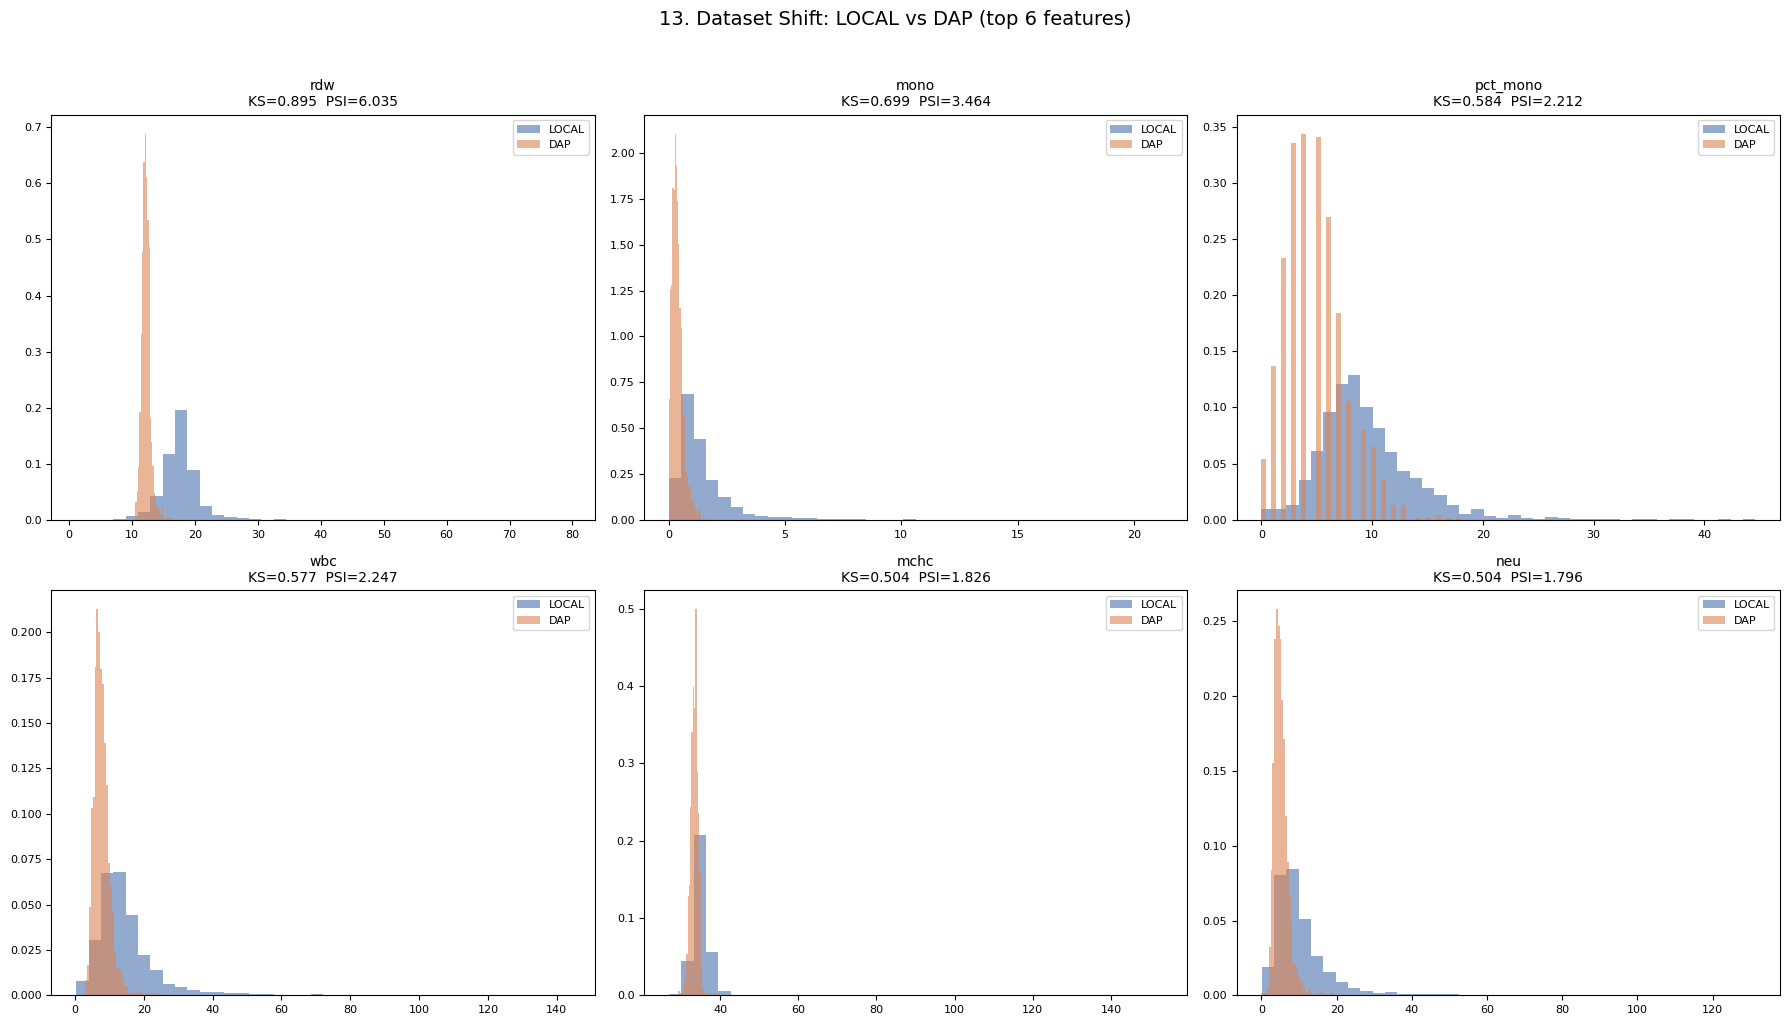


=== Shift temporal por batch (medianas de PLT, WBC, HCT) ===

  plt_value      : CV inter-batch = 21.3%
  wbc_value      : CV inter-batch = 24.0%
  hct_value      : CV inter-batch = 11.7%


In [28]:
# -- 13b. Visualización de distribuciones con shift -------------
import matplotlib.pyplot as plt

# Seleccionar top 6 features con mayor KS statistic
top_shift = df_shift.nlargest(6, "ks_stat")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(top_shift.iterrows()):
    ax = axes[i]
    feat = f"{row['feature']}_value"
    
    local_vals = local_sub[feat].dropna()
    dap_vals = dap_sub[feat].dropna()
    
    ax.hist(local_vals, bins=40, alpha=0.6, density=True, label="LOCAL", color="#4c72b0")
    ax.hist(dap_vals, bins=40, alpha=0.6, density=True, label="DAP", color="#dd8452")
    
    ax.set_title(f"{row['feature']}\nKS={row['ks_stat']:.3f}  PSI={row['psi']:.3f}",
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle("13. Dataset Shift: LOCAL vs DAP (top 6 features)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Shift temporal por batch (solo LOCAL) ---
if "batch" in df_combined.columns:
    local_batches = df_combined[df_combined["source"] == "LOCAL"]
    numeric_batches = pd.to_numeric(local_batches["batch"], errors="coerce").dropna()
    if len(numeric_batches) > 10:
        print("\n=== Shift temporal por batch (medianas de PLT, WBC, HCT) ===\n")
        for analyte in ["plt_value", "wbc_value", "hct_value"]:
            batch_medians = local_batches.groupby("batch")[analyte].median().dropna()
            if len(batch_medians) > 5:
                cv = batch_medians.std() / batch_medians.mean() * 100
                print(f"  {analyte:15s}: CV inter-batch = {cv:.1f}%")

---
## 14. Re-exportar Dataset Enriquecido

Se re-exporta el dataset combinado con las nuevas columnas de calidad y targets core.

In [29]:
# -- 14. Re-exportar CSV enriquecido ---------------------------

# Nuevas columnas a incluir
new_cols = [
    "schema_violations", "quality_tier",
    "label_CORE_TROMBOCITOPENIA", "trombocitopenia_severity",
    "label_CORE_LINFOPENIA", "label_CORE_LINFOCITOSIS",
    "label_confidence_score",
]

# Reordenar columnas
existing_cols = [c for c in df_combined.columns if c not in new_cols]
final_cols = existing_cols + [c for c in new_cols if c in df_combined.columns]
df_combined = df_combined[final_cols]

# Guardar combinado
csv_combined = DATA_DIR / "hemogramas_combinado.csv"
df_combined.to_csv(csv_combined, index=False)
print(f"CSV combinado enriquecido: {csv_combined}")
print(f"  Shape: {df_combined.shape}")
print(f"  Columnas nuevas: {[c for c in new_cols if c in df_combined.columns]}")

# Re-exportar solo local
df_local_v2 = df_combined[df_combined["source"] == "LOCAL"].drop(
    columns=["source", "fingerprint", "is_duplicate"], errors="ignore"
)
csv_local = DATA_DIR / "hemogramas_extraidos.csv"
df_local_v2.to_csv(csv_local, index=False)
print(f"\nCSV local (compatibilidad): {csv_local}")
print(f"  Shape: {df_local_v2.shape}")

print("\n=== Pipeline de datos completo ===")

CSV combinado enriquecido: ../data2/hemogramas_combinado.csv
  Shape: (4160, 176)
  Columnas nuevas: ['schema_violations', 'quality_tier', 'label_CORE_TROMBOCITOPENIA', 'trombocitopenia_severity', 'label_CORE_LINFOPENIA', 'label_CORE_LINFOCITOSIS', 'label_confidence_score']

CSV local (compatibilidad): ../data2/hemogramas_extraidos.csv
  Shape: (2479, 173)

=== Pipeline de datos completo ===
